# Python lab · Statistical Arbitrage & Pairs Trading

Notebook นี้รวมบทเรียนห้าตอนจาก Markdown ต้นฉบับ พร้อมโค้ดที่รันตามลำดับได้และผลที่คำนวณแล้ว
การจำลองและโมเดลใช้ **NumPy, SciPy และ statsmodels** หากยังไม่มีให้ติดตั้งด้วย
`python -m pip install numpy scipy statsmodels` ใน environment ที่เลือกเป็น kernel ก่อนกด Run All
ไม่ต้องดาวน์โหลดข้อมูลตลาด ไม่ต้องมี API key และไม่ต้องเปิดไฟล์โค้ดอื่น

กราฟทั้งสิบสามเป็น snapshot ของพารามิเตอร์และ seed ที่ระบุ ฝังอยู่ในไฟล์แล้ว เมื่อแก้พารามิเตอร์
ผลจากโค้ดจะเปลี่ยน แต่ภาพ snapshot จะไม่เปลี่ยนตาม ห้องทดลอง Backtest แบบมีสถานะและต้นทุน
อยู่ในเว็บไซต์ ตัวอย่าง Python เน้นบัญชีกำไรสองขา การคัดคู่ และการประเมิน forecast
ตัวทดลองซื้อขายใช้ข้อมูลสมมติ ไม่ใช่ผลการลงทุนในตลาดจริง ส่วนกรณี EUR/CHF ในตอน 5
ใช้ข้อมูลอ้างอิง ECB จริงที่ฝังไว้ พร้อมแยกการคำนวณ returns และ EWMA ของผู้เขียนออกจากข้อมูลต้นฉบับ

In [1]:
"""Reproducible, hypothetical pairs research; not a market backtest.

Requires numpy and statsmodels. All parameters and candidate models are fixed
before the held-out evaluation. The generated process is deliberately simple:
it teaches separation of estimation, selection and evaluation, not tradability.
"""
import json
import sys
from importlib.metadata import version
from pathlib import Path

import numpy as np
from statsmodels.tsa.stattools import coint

SEED, N, HORIZON, TRAIN_END, VALID_END, LOOKBACK = 260920, 1200, 5, 720, 960, 20
ALPHAS = (0.0, 0.1, 1.0, 10.0, 100.0, 1000.0)
FEATURE_NAMES = ("residual_z", "residual_change_1d", "residual_change_5d",
                 "residual_change_sd_20d", "B_return_5d")


def simulate_pair(seed=SEED, n=N):
    """USD/share levels: B random walk; A = 18 + 1.15 B + AR(1) noise."""
    rng = np.random.default_rng(seed)
    b = 100 + np.cumsum(rng.normal(0, 0.55, n))
    innovations = rng.normal(0, 0.8, n)
    spread = np.empty(n)
    spread[0] = innovations[0] / np.sqrt(1 - 0.91**2)
    for t in range(1, n):
        spread[t] = 0.91 * spread[t - 1] + innovations[t]
    a = 18 + 1.15 * b + spread
    assert np.all(a > 0) and np.all(b > 0), "This seed must have positive prices."
    return {"a": a, "b": b, "true_spread": spread}


def hedge_and_features(a, b):
    """Freeze estimates at the training cutoff; each row uses data through t.

    Training rows are retrospective training examples, not historical trading
    signals. Frozen estimates become available before validation begins.
    """
    design = np.column_stack((np.ones(TRAIN_END), b[:TRAIN_END]))
    intercept, hedge = np.linalg.lstsq(design, a[:TRAIN_END], rcond=None)[0]
    residual = a - intercept - hedge * b
    center = residual[:TRAIN_END].mean()
    scale = residual[:TRAIN_END].std(ddof=1)
    z = (residual - center) / scale
    times = np.arange(LOOKBACK, len(a) - HORIZON)
    features = np.array([
        [z[t], residual[t] - residual[t - 1], residual[t] - residual[t - 5],
         np.diff(residual[t - LOOKBACK:t + 1]).std(ddof=1),
         b[t] / b[t - 5] - 1]
        for t in times
    ])
    target = residual[times + HORIZON] - residual[times]
    masks = {
        "train": times + HORIZON < TRAIN_END,
        "validation": (times >= TRAIN_END) & (times + HORIZON < VALID_END),
        "test": times >= VALID_END,
    }
    return {"times": times, "features": features, "target": target,
            "residual": residual, "z": z, "masks": masks,
            "intercept": float(intercept), "hedge": float(hedge),
            "residual_center": float(center), "residual_sd": float(scale)}


def ridge_fit(x, y, alpha):
    """Minimize sum((y-b0-Xb)^2) + alpha*sum(b^2); intercept unpenalized."""
    center, scale = x.mean(axis=0), x.std(axis=0, ddof=0)
    scale = np.where(scale > 1e-12, scale, 1)
    standardized = (x - center) / scale
    y_mean = y.mean()
    coefficients = np.linalg.solve(standardized.T @ standardized + alpha * np.eye(x.shape[1]),
                                   standardized.T @ (y - y_mean))
    return {"center": center, "scale": scale, "coefficients": coefficients,
            "intercept": float(y_mean)}


def ridge_predict(model, x):
    return ((x - model["center"]) / model["scale"]) @ model["coefficients"] + model["intercept"]


def metrics(actual, predicted):
    error = actual - predicted
    return {"mae_usd": float(np.mean(np.abs(error))),
            "rmse_usd": float(np.sqrt(np.mean(error**2))),
            "n": int(len(actual))}


def run_research(pair=None):
    pair = simulate_pair() if pair is None else pair
    prepared = hedge_and_features(pair["a"], pair["b"])
    x, y, masks = prepared["features"], prepared["target"], prepared["masks"]
    candidates = []
    for alpha in ALPHAS:
        model = ridge_fit(x[masks["train"]], y[masks["train"]], alpha)
        predicted = ridge_predict(model, x[masks["validation"]])
        candidates.append({"alpha": alpha, "validation_mse_usd2": float(np.mean((y[masks["validation"]] - predicted)**2))})
    selected = min(candidates, key=lambda row: row["validation_mse_usd2"])["alpha"]
    # No train+validation refit: the originally trained candidate stays frozen.
    model = ridge_fit(x[masks["train"]], y[masks["train"]], selected)
    predicted = ridge_predict(model, x)
    residual = prepared["residual"]
    ar_intercept, ar_phi = np.linalg.lstsq(
        np.column_stack((np.ones(TRAIN_END - 1), residual[:TRAIN_END - 1])),
        residual[1:TRAIN_END], rcond=None)[0]
    current = residual[prepared["times"]]
    ar_prediction = ((ar_phi**HORIZON - 1) * current
                     + ar_intercept * sum(ar_phi**i for i in range(HORIZON)))
    score = {split: {
        "ridge": metrics(y[mask], predicted[mask]),
        "zero_change": metrics(y[mask], np.zeros(np.sum(mask))),
        "ar1": metrics(y[mask], ar_prediction[mask]),
    } for split, mask in masks.items() if split != "train"}
    statistic, pvalue, critical = coint(pair["a"][:TRAIN_END], pair["b"][:TRAIN_END],
                                      trend="c", maxlag=5, autolag="aic")
    summary = {
        "kind": "hypothetical_simulation_not_market_backtest", "seed": SEED,
        "software_versions": {"python": sys.version.split()[0],
                              **{name: version(name) for name in ("numpy", "scipy", "statsmodels")}},
        "observations": N, "price_unit": "USD per share", "horizon_days": HORIZON,
        "data_generation": {"B": "100 + cumulative Normal(0, 0.55^2)",
                            "A": "18 + 1.15*B + e", "e": "0.91*lag(e) + Normal(0, 0.8^2)",
                            "initial_e": "Normal(0, 0.8^2/(1-0.91^2))"},
        "split": {"training_price_days": [0, TRAIN_END - 1],
                  "training_origins": [LOOKBACK, TRAIN_END - HORIZON - 1],
                  "validation_origins": [TRAIN_END, VALID_END - HORIZON - 1],
                  "test_origins": [VALID_END, N - HORIZON - 1],
                  "purged_origins": [[TRAIN_END - HORIZON, TRAIN_END - 1],
                                     [VALID_END - HORIZON, VALID_END - 1]],
                  "unlabeled_final_origins": [N - HORIZON, N - 1],
                  "counts": {key: int(mask.sum()) for key, mask in masks.items()}},
        "hedge": {key: prepared[key] for key in ("intercept", "hedge", "residual_center", "residual_sd")},
        "features": list(FEATURE_NAMES), "target": "residual[t+5] - residual[t], USD/share of A",
        "ridge": {"objective": "SSE + alpha * squared_L2_coefficients", "candidates": candidates,
                  "selected_alpha": selected, "train_feature_means": model["center"].tolist(),
                  "train_feature_scales": model["scale"].tolist(), "coefficients": model["coefficients"].tolist(),
                  "intercept": model["intercept"], "refit_after_validation": False},
        "ar1": {"intercept": float(ar_intercept), "phi": float(ar_phi), "fit_price_days": [0, TRAIN_END - 1]},
        "engle_granger": {"sample": "training prices only", "trend": "c", "maxlag": 5, "autolag": "aic",
                          "statistic": float(statistic), "approximate_pvalue": float(pvalue),
                          "critical_values_1_5_10_percent": critical.tolist()},
        "metrics": score,
        "limitations": ["Synthetic AR(1) residual favors mean-reversion models by construction.",
                        "Five-day targets overlap; n is not a count of independent observations.",
                        "No fills, transaction costs, borrowing, dividends, positions or portfolio returns are modeled.",
                        "The close-t forecast is not a same-close execution assumption.",
                        "Selection uses validation MSE once; test is only a held-out evaluation.",
                        "Approximate cointegration p-value is not a probability of future convergence."],
    }
    return {"pair": pair, "prepared": prepared, "model": model, "predicted": predicted,
            "ar_prediction": ar_prediction, "summary": summary}


def synthetic_universe():
    """Six labeled securities, 720 returns, two known latent factor groups."""
    rng = np.random.default_rng(SEED + 1)
    factors = rng.normal(size=(TRAIN_END, 2))
    loadings = np.array([[1.0, 0.1], [0.9, 0.1], [0.8, 0.2],
                         [0.1, 1.0], [0.1, 0.9], [0.2, 0.8]])
    returns = 0.01 * (factors @ loadings.T + rng.normal(0, 0.5, size=(TRAIN_END, 6)))
    standardized = (returns - returns.mean(axis=0)) / returns.std(axis=0, ddof=1)
    corr = np.corrcoef(returns, rowvar=False)
    _, singular, vt = np.linalg.svd(standardized, full_matrices=False)
    # Fix arbitrary PCA signs for reproducible display; signs have no interpretation.
    for row in vt:
        if row[np.argmax(np.abs(row))] < 0:
            row *= -1
    eigenvalues = singular**2 / (len(returns) - 1)
    return {"returns": returns, "correlation": corr, "components": vt,
            "explained_ratio": eigenvalues / eigenvalues.sum(),
            "labels": ["A", "B", "C", "D", "E", "F"]}


def verify_research(result):
    """Audit boundary leakage and accounting semantics, not model profitability."""
    p = result["prepared"]
    for split, boundary in (("train", TRAIN_END), ("validation", VALID_END)):
        assert np.max(p["times"][p["masks"][split]] + HORIZON) < boundary
    masks = list(p["masks"].values())
    assert not np.any(sum(mask.astype(int) for mask in masks) > 1)
    # Changing test prices must leave hedge, selected alpha and trained weights unchanged.
    modified = {key: value.copy() for key, value in result["pair"].items()}
    modified["a"][VALID_END:] += 3 * np.sin(np.arange(N - VALID_END) / 4)
    revised = run_research(modified)
    assert result["summary"]["hedge"] == revised["summary"]["hedge"]
    assert result["summary"]["ridge"] == revised["summary"]["ridge"]
    assert result["summary"]["metrics"]["validation"] == revised["summary"]["metrics"]["validation"]
    # A future edit changes its target, not the features available at an origin.
    origin = VALID_END + 20
    modified = {key: value.copy() for key, value in result["pair"].items()}
    modified["a"][origin + 1:] += 7
    changed = hedge_and_features(modified["a"], modified["b"])
    index = np.flatnonzero(p["times"] == origin)[0]
    np.testing.assert_allclose(changed["features"][index], p["features"][index], atol=0, rtol=0)
    np.testing.assert_allclose(changed["target"][index] - p["target"][index], 7)
    # Equal dollar long/short returns use gross = 2*leg_notional.
    for long_return, short_asset_return in ((0.10, 0.05), (-0.05, -0.10), (-0.10, 0.10)):
        pnl = 10000 * long_return - 10000 * short_asset_return
        assert np.isclose(pnl / 20000, (long_return - short_asset_return) / 2)
    return ["training and validation labels end before subsequent samples",
            "future test edits leave fitting and validation selection unchanged",
            "future edits do not alter close-t features", "gross-notional P&L identity"]


print("Loaded the self-contained synthetic model, fitting, selection and leakage checks.")

Loaded the self-contained synthetic model, fitting, selection and leakage checks.


# Statistical Arbitrage · เริ่มจาก Pairs Trading

หุ้นสองตัวลงพร้อมกัน พอร์ตที่ซื้อหนึ่งตัวและขายชอร์ตอีกตัวอาจยังมีกำไรได้ ถ้าตัวที่ซื้อเสียหายน้อยกว่าตัวที่ชอร์ต

Pairs Trading ให้เราทดสอบความสัมพันธ์ของสินทรัพย์สองตัว แทนที่จะคาดเดาราคาของสินทรัพย์ตัวเดียว ในซีรีส์นี้เราจะสร้างกลยุทธ์ที่ซื้อด้านซึ่งอ่อนกว่าความสัมพันธ์ที่ประมาณไว้ และขายชอร์ตด้านซึ่งแข็งกว่า แล้วตรวจว่ารายรับจากการกลับเข้าหากันเหลือพอหลังหักต้นทุนหรือไม่

คำว่า Statistical Arbitrage ครอบคลุมกลยุทธ์ที่ใช้ความสัมพันธ์ทางสถิติสร้างสัญญาณซื้อขาย บางกลยุทธ์ถือหลายสิบหรือหลายร้อยสินทรัพย์เพื่อกระจายความเสี่ยง ส่วน Pairs Trading เป็นจุดเริ่มต้นที่เห็นบัญชีกำไรขาดทุนได้ครบทั้งสองขา ความสัมพันธ์ที่เคยพบอาจเปลี่ยนไป และการถือ Long–Short ยังขาดทุนได้

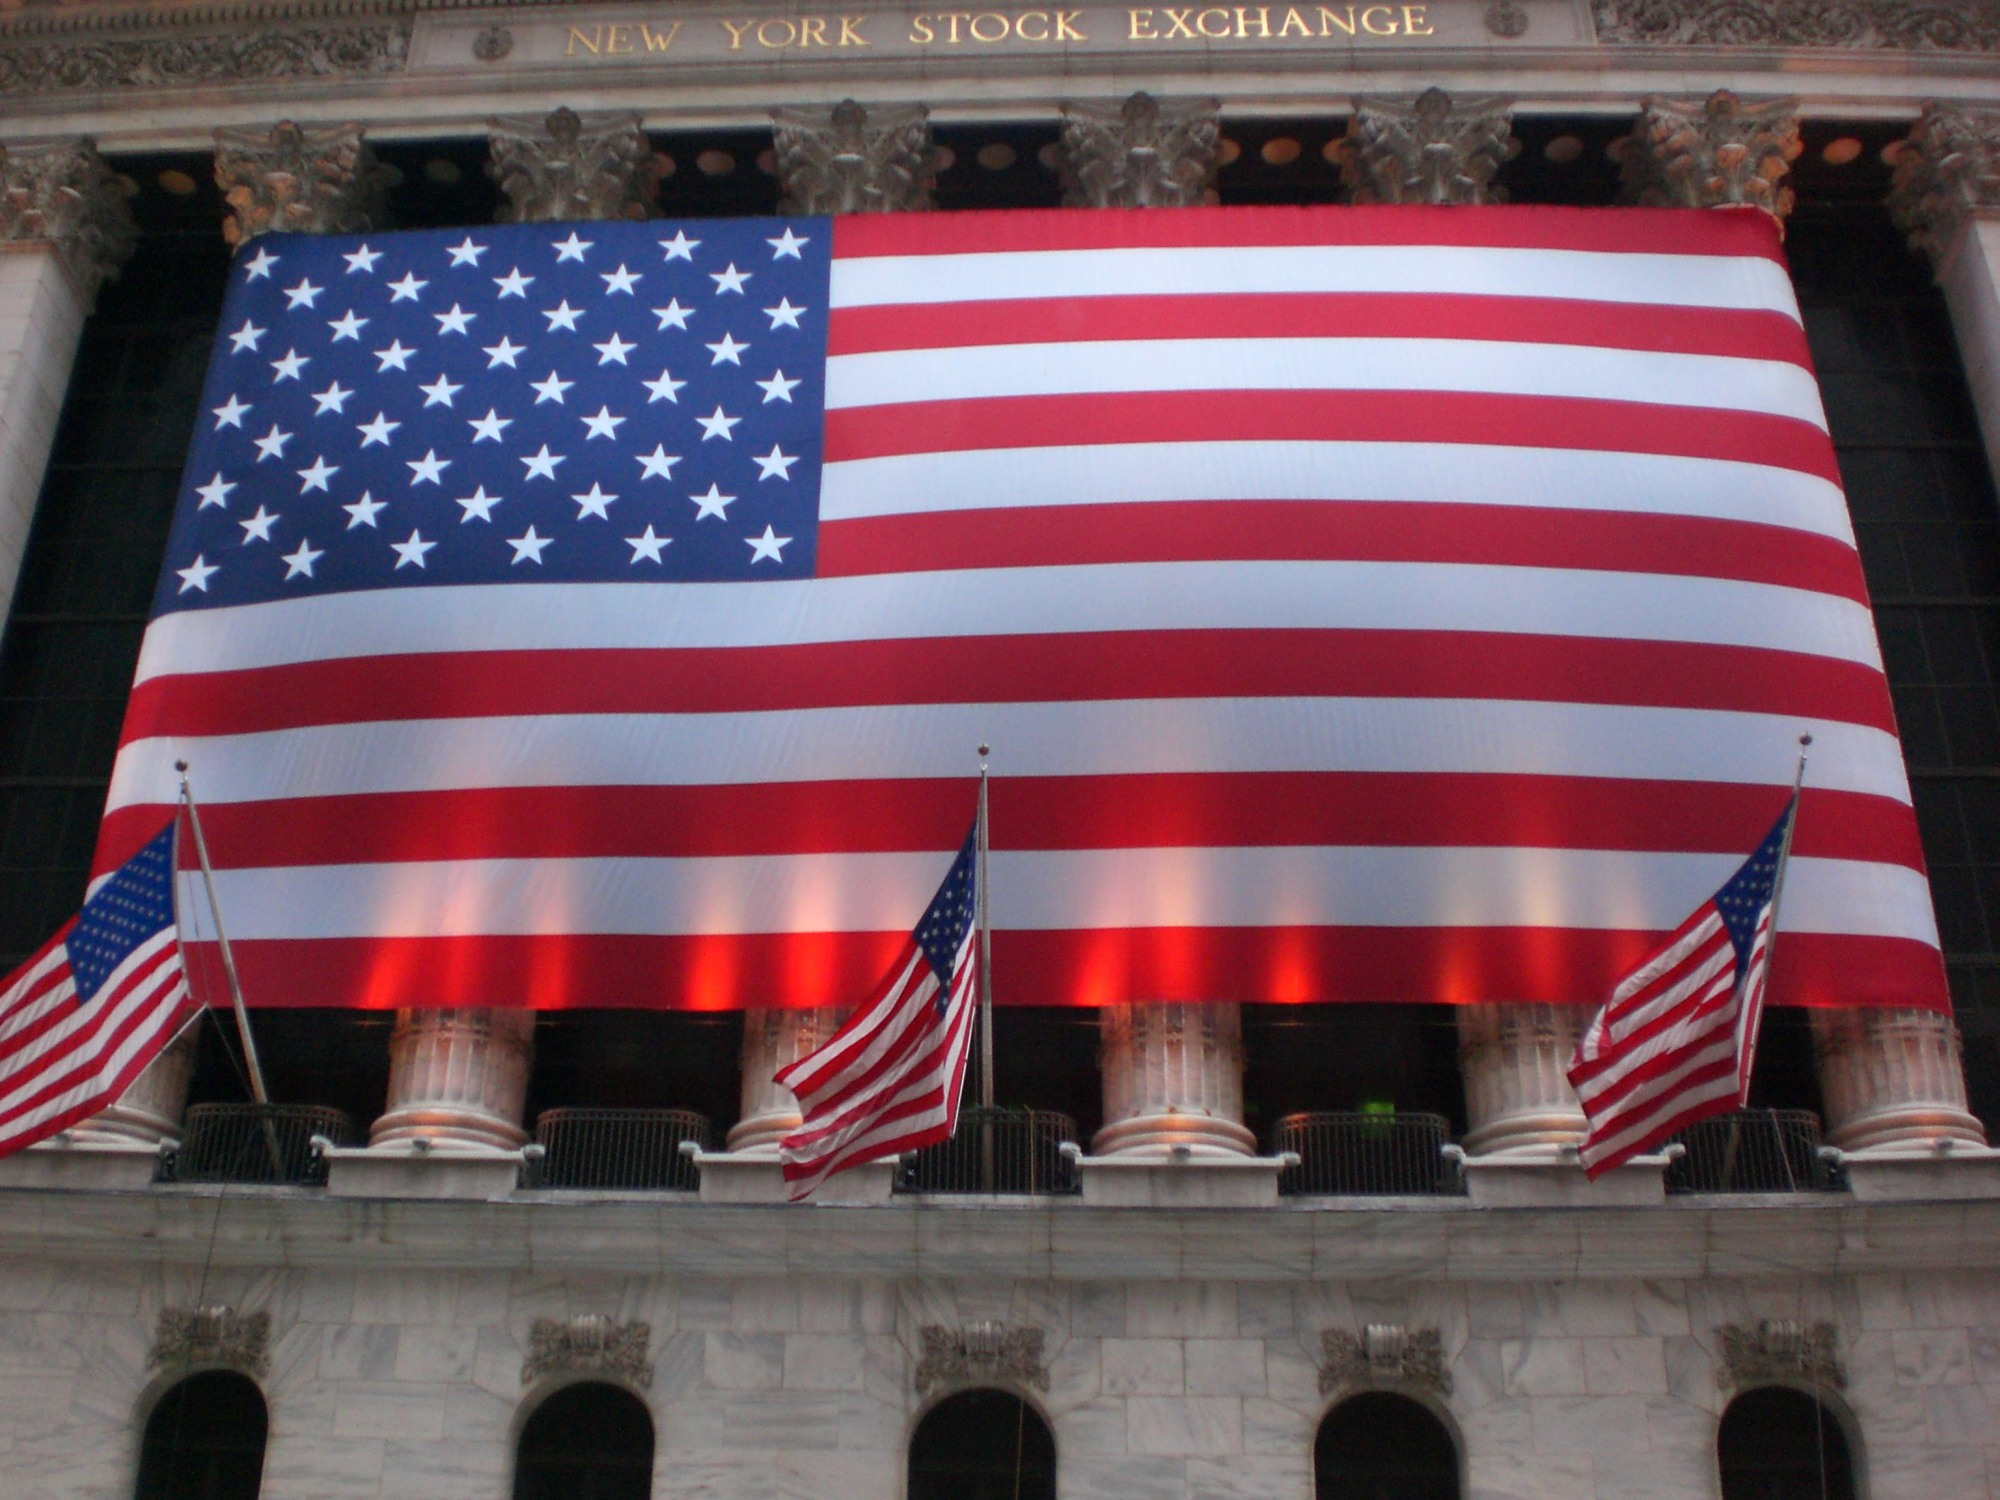

New York Stock Exchange · ภาพโดย [www.elbpresse.de / Chs87](https://commons.wikimedia.org/wiki/File:New_York_Stock_Exchange_-_Frontal_-_NYSE.jpg) · [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) · ภาพต้นฉบับไม่ดัดแปลง ใช้ประกอบบริบทตลาด ไม่ได้แสดงผลของกลยุทธ์

## เส้นทางของซีรีส์

| ตอน | สิ่งที่จะทำได้หลังอ่าน | ภาพและการทดลอง |
|---|---|---|
| 1 · หน้านี้ | แยกกำไรของสองขาและเลือกความเสี่ยงที่ต้องการ hedge | กราฟสามสถานการณ์และตัวปรับ hedge |
| [2 · Cointegration](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-cointegration.html) | สร้าง residual และอ่านผลทดสอบโดยไม่แปล p-value เกินความหมาย | ราคาเทียบ spread และตัวทดลองความสัมพันธ์ที่เปลี่ยนไป |
| [3 · Signals & Backtest](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-backtest.html) | เปลี่ยน z-score เป็นคำสั่งซื้อขายพร้อมสมุดบัญชีต้นทุน | กราฟ signal, equity และ trade blotter |
| [4 · Clustering, PCA & Prediction](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-ml.html) | คัดกลุ่มหุ้นและทดสอบโมเดลทำนายด้วยข้อมูลตามลำดับเวลา | Heatmap, dendrogram, PCA และ Notebook ที่รันได้ |

ใช้ความรู้เรื่อง [Returns](https://nutdnuy.github.io/quantitative-finance-notes/prices-and-returns.html), ค่าเฉลี่ย, ส่วนเบี่ยงเบนมาตรฐาน และเส้นถดถอยเชิงเส้นประกอบได้ ตัวเลข A/B และผลทดลองในซีรีส์เป็นข้อมูลสมมติทั้งหมด ไม่มีคู่หุ้นแนะนำหรือผล Backtest ของตลาดจริง

## อ่านกำไรขาดทุนทีละขา

สมมติซื้อหุ้น A มูลค่า 10,000 ดอลลาร์ และ [ขายชอร์ต](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#short-selling) หุ้น B มูลค่า 10,000 ดอลลาร์ เมื่อปิดทั้งสองขา กำไรก่อนต้นทุนคือ

$$
\Pi=10{,}000r_A-10{,}000r_B.
$$

\(r_A,r_B\) คือ simple return ระหว่างเปิดและปิดสถานะ ไม่รวมเงินปันผล เครื่องหมายลบของขา B มาจากการขายก่อนแล้วซื้อคืน ถ้าราคา B ลง ขานี้จะมีกำไร

| ราคาช่วงที่ถือ | P&L ของ Long A | P&L ของ Short B | P&L รวม |
|---|---:|---:|---:|
| A +5%, B −5% | +500 | +500 | +1,000 ดอลลาร์ |
| A +15%, B +5% | +1,500 | −500 | +1,000 ดอลลาร์ |
| A −5%, B −15% | −500 | +1,500 | +1,000 ดอลลาร์ |

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะกราฟเพื่อเปิดขนาดเต็ม



ตัวอย่างสมมติเดียวกันทั้งสามกรณี · Long และ Short มีมูลค่าเริ่มต้นเท่ากัน · ยังไม่หักต้นทุน

ส่วนต่าง \(r_A-r_B=10\%\) ยังต้องมีฐานเงินทุนก่อนเรียกว่า “ผลตอบแทนพอร์ต” ถ้าวัดเทียบ [gross notional](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#gross-notional) 20,000 ดอลลาร์ จะได้ 1,000 / 20,000 = 5% หากกันเงินทุนไว้ 25,000 ดอลลาร์ จะได้ 4% เงินสดสุทธิจากการเปิดสองขาอาจใกล้ศูนย์ แต่ผู้ซื้อขายยังต้องมีหลักประกันและรับความเสี่ยง ห้ามนำกำไรไปหารด้วยเงินลงทุนสุทธิที่ใกล้ศูนย์

เมื่อปรับมูลค่าสองขาไม่เท่ากัน สูตรต้องกลับไปใช้ \(\Pi=N_A r_A-N_B r_B\) โดย \(N_A,N_B\) เป็นมูลค่าแต่ละขาตอนเปิด การลบเปอร์เซ็นต์ตรง ๆ จะไม่ให้ P&L ของพอร์ตนั้นแล้ว

In [2]:
leg_notional, account_equity = 10_000, 25_000
gross_notional = 2 * leg_notional
scenarios = [(0.05, -0.05), (0.15, 0.05), (-0.05, -0.15)]
print(" A return  B return   long P&L   short P&L   pair P&L   P&L/gross  P&L/equity")
for ra, rb in scenarios:
    long_pnl, short_pnl = leg_notional*ra, -leg_notional*rb
    pnl = long_pnl + short_pnl
    assert np.isclose(pnl, 1000)
    assert np.isclose(pnl/gross_notional, .05)
    print(f"{ra:+8.1%} {rb:+8.1%} {long_pnl:10.0f} {short_pnl:11.0f} {pnl:10.0f} {pnl/gross_notional:11.1%} {pnl/account_equity:11.1%}")
adverse_pnl = leg_notional*(-.10) - leg_notional*.10
assert adverse_pnl == -2000
print(f"Adverse case A -10%, B +10%: P&L {adverse_pnl:,.0f} USD; gross-based return {adverse_pnl/gross_notional:.1%}.")
print("Hypothetical simple price returns; fees, dividends and borrow costs excluded.")

 A return  B return   long P&L   short P&L   pair P&L   P&L/gross  P&L/equity
   +5.0%    -5.0%        500         500       1000        5.0%        4.0%
  +15.0%    +5.0%       1500        -500       1000        5.0%        4.0%
   -5.0%   -15.0%       -500        1500       1000        5.0%        4.0%
Adverse case A -10%, B +10%: P&L -2,000 USD; gross-based return -10.0%.
Hypothetical simple price returns; fees, dividends and borrow costs excluded.


## Hedge ratio สามแบบตอบคนละโจทย์

Dollar neutral กำหนดให้มูลค่า Long เท่ากับมูลค่า Short ส่วน beta neutral กำหนดให้ความไวต่อตลาดของสองขาหักล้างกัน โดยประมาณ market beta จากผลตอบแทนที่สอดคล้องกันทั้งช่วงเวลาและ benchmark

$$
\beta_i=\frac{\operatorname{Cov}(r_i,r_M)}{\operatorname{Var}(r_M)},\qquad
\beta_A N_A-\beta_B N_B=0.
$$

ถ้าซื้อ A 10,000 ดอลลาร์ โดย \(\beta_A=1.2\) และ \(\beta_B=0.8\) จะต้องขายชอร์ต B 15,000 ดอลลาร์เพื่อให้ beta exposure ประมาณศูนย์ พอร์ตนี้มี gross notional 25,000 ดอลลาร์ และ net notional −5,000 ดอลลาร์

จำนวนหุ้นยังขึ้นกับราคา เช่น A ราคา 100 และ B ราคา 50 ดอลลาร์ จะถือ A +100 หุ้น และ B −300 หุ้น ถ้าจะปัดจำนวนหุ้น ต้องคำนวณ exposure ที่เหลืออีกครั้ง Market beta เป็นค่าประมาณในอดีต จึงเปลี่ยนได้หลังเปิดสถานะ และไม่ได้ครอบคลุมความเสี่ยงของบริษัทแต่ละแห่ง

| วิธี | เงื่อนไข | สิ่งที่ยังเหลืออยู่ |
|---|---|---|
| Dollar neutral | \(N_A=N_B\) | market beta อาจไม่เท่ากัน |
| Market-beta neutral | \(\beta_A N_A=\beta_B N_B\) | ความเสี่ยงเฉพาะบริษัทและ beta ที่เปลี่ยน |
| Cointegration hedge | เลือก h ให้ \(P_A-\alpha-hP_B\) มีคุณสมบัติที่ต้องการ | ไม่บังคับให้ dollar หรือ market beta เป็นศูนย์ |

เราจะใช้ h แทนสัมประสิทธิ์ของราคาในตอนถัดไป เพื่อแยกจาก market beta สำหรับ regression ของราคาในหน่วยดอลลาร์ต่อหุ้น h แปลเป็นจำนวนหุ้น B ต่อหุ้น A ได้ ส่วน regression ของ log price ให้สัมประสิทธิ์ที่ต้องแปลงเป็นมูลค่าขาและจำนวนหุ้นอีกขั้น

*ห้องทดลองแบบปรับค่าอยู่ในหน้าเว็บไซต์; Notebook นี้ใช้ตัวอย่าง Python ด้านล่าง*

ลองขยับผลตอบแทนตลาดโดยตรึงส่วนต่างเฉพาะคู่ไว้ แล้วเปรียบเทียบการถือมูลค่าเท่ากันกับ beta neutral ตัวทดลองใช้สมการผลตอบแทนเชิงเส้นที่กำหนด beta คงที่ จึงแสดงการ hedge ภายใต้แบบจำลองนี้ได้ชัดกว่าการประมาณ beta จากตลาดจริง

In [3]:
beta_a, beta_b, notional_a = 1.2, .8, 10_000
price_a, price_b = 100, 50
notional_b = beta_a * notional_a / beta_b
net_beta_dollars = beta_a * notional_a - beta_b * notional_b
assert np.isclose(net_beta_dollars, 0)
print(f"Beta-neutral: long A {notional_a:,.0f} USD; short B {notional_b:,.0f} USD")
print(f"Shares: A +{notional_a/price_a:g}, B {-notional_b/price_b:g}")
print(f"Gross: {notional_a+notional_b:,.0f}; net: {notional_a-notional_b:,.0f} USD")
print("Neutrality holds only for these specified constant betas; this is not the price-regression hedge.")

Beta-neutral: long A 10,000 USD; short B 15,000 USD
Shares: A +100, B -300
Gross: 25,000; net: -5,000 USD
Neutrality holds only for these specified constant betas; this is not the price-regression hedge.


## เริ่มจากเหตุผลที่สินทรัพย์ควรสัมพันธ์กัน

ธุรกิจที่มีรายได้จากตลาดเดียวกัน วัตถุดิบชนิดเดียวกัน หรือสินทรัพย์ที่รับปัจจัยตลาดร่วมกัน อาจเป็นผู้สมัครที่น่าศึกษา เราต้องตรวจด้วยว่าบริษัทมีสัดส่วนหนี้ การเติบโต สกุลเงิน และเหตุการณ์เฉพาะตัวต่างกันเพียงใด การอยู่ในอุตสาหกรรมเดียวกันยังไม่ทำให้ผลตอบแทนหรือ valuation เหมือนกัน

ก่อนสแกนคู่ ให้กำหนด universe และช่วงข้อมูลจากสิ่งที่รู้ได้ ณ วันนั้น เลือกความถี่เดียวกัน จัดวันซื้อขายให้ตรง ตรวจ split, dividend, missing values และสิทธิ์ในการขายชอร์ต ถ้าใช้หุ้นที่ยังอยู่ในดัชนีวันนี้ย้อนหลังไปทั้งช่วง จะตัดบริษัทที่ออกจากดัชนีหรือหายไปจากตลาดออกโดยไม่รู้ตัว

งานของ Gatev, Goetzmann และ Rouwenhorst ใช้ระยะห่างของราคาที่ปรับมาตราส่วนเป็นวิธีเลือกคู่ ขณะที่ซีรีส์นี้จะทดลองแนว Cointegration ก่อน ทั้งสองวิธีควรมีกติกาทดสอบที่ระบุไว้ล่วงหน้า อ่านกรอบงานเดิมที่ [Pairs Trading: Performance of a Relative Value Arbitrage Rule](https://www.nber.org/papers/w7032)

ขาต่อไปคือการตรวจว่า เมื่อราคาทั้งคู่เคลื่อนไปตามเวลาแล้ว ส่วนที่เหลือหลังหักความสัมพันธ์ยังแกว่งอยู่รอบระดับเดิมหรือไม่ → [ตอน 2 · Cointegration](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-cointegration.html)

## อ่านและทดลองต่อ

เอกสารประกอบตอนนี้คือ *Module PDF — Build a Pair Trading strategy prediction model* หน้า 1–36 ที่ผู้ใช้ให้มา เราเรียบเรียงใหม่และคำนวณฐานผลตอบแทนให้ชัด ตัวเลขในเอกสารเป็นตัวอย่างของช่วงที่จัดทำ ไม่ใช่ราคาและ beta ปัจจุบัน ดู [บันทึกแหล่งข้อมูลและการแก้ความคลาดเคลื่อน](https://nutdnuy.github.io/statistical-arbitrage/data/pairs-trading-provenance.json)

[ดาวน์โหลด Notebook ทั้งซีรีส์](https://nutdnuy.github.io/statistical-arbitrage/notebooks/pairs-trading.ipynb) · [Coursera: Using Machine Learning in Trading and Finance](https://www.coursera.org/learn/machine-learning-trading-finance) · [วิดีโอที่ใช้เป็นแหล่งอ่านต่อ: Basic Statistical Arbitrage](https://www.youtube.com/watch?v=g-qvFjvyqcs&t=23s)

# Pairs Trading 2 · Cointegration

กราฟราคาสองเส้นอาจดูคล้ายกัน แต่ส่วนต่างของมันอาจเคลื่อนห่างออกไปเรื่อย ๆ

[ตอนแรก](https://nutdnuy.github.io/statistical-arbitrage/statistical-arbitrage.html) แยกกำไรขาดทุนของ Long–Short แล้ว ตอนนี้เราจะตรวจสมมติฐานที่ทำให้กลยุทธ์ซื้อด้านอ่อนและขายด้านแข็งมีเหตุผล หากส่วนต่างกำลังเปลี่ยนไปอย่างถาวร การรอให้มันกลับอาจทำให้ถือขาดทุนนานขึ้น

## Correlation บอกการเคลื่อนไหวร่วมกัน

Correlation ของผลตอบแทนบอกความสัมพันธ์เชิงเส้นในช่วงข้อมูลที่วัด ค่าใกล้ 1 หมายถึงวันที่ A ให้ผลตอบแทนสูงกว่าค่าเฉลี่ย B ก็มักให้ผลตอบแทนสูงกว่าค่าเฉลี่ยด้วย มันไม่ได้กำหนดว่าราคาสองเส้นต้องกลับมามีส่วนต่างเท่าเดิม

ลองสร้างอนุกรมจากช็อกอิสระสองชุด โดย \(X_t\) และ \(Y_t\) เป็น random walk

$$
B_t=X_t,\qquad A_t=X_t+0.2Y_t.
$$

หากช็อกแต่ละชุดมี variance เท่ากัน correlation ของผลต่างหนึ่งช่วงเท่ากับ \(1/\sqrt{1+0.2^2}\approx0.981\) แต่ \(A_t-B_t=0.2Y_t\) ยังเป็น random walk และ variance โตตามเวลา ตัวอย่างนี้เป็นระดับอนุกรมสมมติ ผลต่างของระดับยังไม่ใช่เปอร์เซ็นต์ผลตอบแทนของหุ้น

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะกราฟเพื่อเปิดขนาดเต็ม



ข้อมูลจำลอง · อ่านกราฟ residual ควบคู่กับกราฟระดับราคา · เส้นที่ดูคล้ายกันในช่วงสั้นยังใช้ยืนยัน stationarity ไม่ได้

## Cointegration ตรวจส่วนผสมของอนุกรม

สำหรับกรณีสองตัวแปรที่เราจะใช้ ถ้า \(P_{A,t}\) และ \(P_{B,t}\) เป็น I(1) คือไม่ stationary ในระดับ แต่ผลต่างลำดับหนึ่งเป็น I(0) และมีค่าคงที่ \(\alpha,h\) ที่ทำให้

$$
s_t=P_{A,t}-\alpha-hP_{B,t}
$$

เป็น I(0) เราเรียกว่าคู่นี้มี [cointegration](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#cointegration) โดย \(s_t\) คือ residual หรือ [spread](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#pair-spread) ที่นิยามด้วยสมการนี้ ทบทวน [stationarity](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#stationarity) ได้ก่อนอ่านต่อ การเรียก I(0) ต้องอาศัยสมมติฐานเรื่องกระบวนการและความสัมพันธ์ตามเวลา มากกว่าดูว่าเส้นหนึ่งดูราบ

ตัวอย่างที่เรากำหนดโครงสร้างเองคือ

$$
P_{B,t}=X_t,\qquad P_{A,t}=20+1.3X_t+u_t,\qquad
u_t=0.8u_{t-1}+\varepsilon_t.
$$

\(X_t\) มี stochastic trend ส่วน \(u_t\) เป็น AR(1) ที่ \(|0.8|<1\) และเริ่มจากการแจกแจง stationary การลบ \(20+1.3P_{B,t}\) ออกจาก A จะเหลือ \(u_t\) การลบราคา A−B ตรง ๆ กลับเหลือ \(20+0.3X_t+u_t\) ซึ่งยังมี trend ร่วมติดอยู่ ค่า h จึงเปลี่ยนสิ่งที่เรากำลังทดสอบ

แบบจำลองเชิงบวกสำหรับราคาหุ้นจริงอาจใช้ log price แต่ห้ามสลับหน่วยกลางทาง ถ้าสัญญาณเป็น \(\log P_A-\alpha-h\log P_B\) สัมประสิทธิ์ h เป็นความสัมพันธ์ใน log scale; ส่วน P&L ต้องคำนวณจากจำนวนหุ้นและราคาซื้อขายจริง

In [4]:
result = run_research()
prepared = result["prepared"]
print("Synthetic prices only; n=1200; seed=260920")
print("Generated A = 18 + 1.15 B + AR(1) noise; phi=0.91, innovation SD=0.8 USD.")
print(f"OLS fit uses prices 0..719 only: intercept={prepared['intercept']:.6f}, h={prepared['hedge']:.6f}")
print(f"Training residual SD={prepared['residual_sd']:.6f} USD/share of A")
print("These estimates are frozen before validation; training rows use the retrospective train fit.")

Synthetic prices only; n=1200; seed=260920
Generated A = 18 + 1.15 B + AR(1) noise; phi=0.91, innovation SD=0.8 USD.
OLS fit uses prices 0..719 only: intercept=20.251497, h=1.129832
Training residual SD=1.838928 USD/share of A
These estimates are frozen before validation; training rows use the retrospective train fit.


## สองภาพ: Correlation กับ Cointegration แยกกันได้

ในสองรูปนี้ **correlation วัดจากผลต่างหนึ่งช่วง** \(\Delta A_t=A_t-A_{t-1}\) และ \(\Delta B_t\) ไม่ใช่ correlation ของระดับราคา และไม่ใช่เปอร์เซ็นต์ผลตอบแทน ทั้งคู่ใช้ข้อมูลจำลอง 500 จุด พร้อมแสดงระดับอนุกรมด้านบน กราฟกระจายของผลต่างด้านล่างซ้าย และ spread ด้านล่างขวา

### Cointegration without correlation

ให้ \(X_t\) เป็น random walk ที่ช็อกแต่ละช่วงมี variance 1 และ \(u_t\) เป็น white noise อิสระจาก X มี mean 0 และ variance 0.5 แล้วกำหนด

$$
A_t=X_t+u_t,\qquad B_t=X_t-u_t.
$$

ทั้ง A และ B มีแนวโน้มสุ่มร่วมกัน แต่ \(A_t-B_t=2u_t\) เป็น stationary จึงมี cointegration ขณะที่ \(\Delta A_t=\Delta X_t+\Delta u_t\) และ \(\Delta B_t=\Delta X_t-\Delta u_t\) มี covariance เท่ากับ \(1-2(0.5)=0\) ดังนั้น correlation ของผลต่างหนึ่งช่วงตามแบบจำลองจึงเป็นศูนย์ ค่าที่วัดจากตัวอย่างจำนวนจำกัดอาจไม่เท่ากับศูนย์พอดี

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะกราฟเพื่อเปิดขนาดเต็ม



ข้อมูลจำลอง · correlation ของผลต่างหนึ่งช่วง: ค่าตามแบบจำลอง 0; ค่าตัวอย่างคำนวณจริงอยู่ในภาพ · ระดับ A และ B ยังมีแนวโน้มร่วมกัน คำว่า without correlation จึงไม่ได้หมายถึงระดับอนุกรมทุกแบบ

### Correlation without cointegration

กลับมาที่ \(A_t=X_t+0.2Y_t\) และ \(B_t=X_t\) โดย X กับ Y เป็น random walk อิสระ ช็อกของทั้งสองมี variance 1 ผลต่างหนึ่งช่วงมี correlation \(1/\sqrt{1.04}\approx0.981\) แต่ spread \(A_t-B_t=0.2Y_t\) ไม่ stationary เมื่อเริ่ม \(Y_0=0\) จะมี variance เท่ากับ \(0.04t\)

แม้เปลี่ยน hedge ratio เป็น h ก็ยังเหลือ \(A_t-hB_t=(1-h)X_t+0.2Y_t\) ไม่มีค่าคงที่ h ที่หักแนวโน้มสุ่มอิสระทั้งสองออกได้พร้อมกัน จึงไม่มี cointegration ในแบบจำลองนี้

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะกราฟเพื่อเปิดขนาดเต็ม



ข้อมูลจำลอง · correlation ของผลต่างหนึ่งช่วงตามแบบจำลองประมาณ 0.981 · เส้น spread อาจกลับผ่านศูนย์ในบางช่วงได้ แต่ variance ของกระบวนการยังเพิ่มตามเวลา

สถานะ cointegration ของสองตัวอย่างนี้ทราบจากสมการที่ใช้สร้างข้อมูล ไม่ได้ตัดสินจากหน้าตากราฟหรือการผ่านเกณฑ์ correlation ดู [seed สมมติฐาน และค่าที่คำนวณได้](https://nutdnuy.github.io/statistical-arbitrage/data/pairs-cointegration-counterexamples.json)

## ประมาณความสัมพันธ์โดยใช้เฉพาะข้อมูลฝึก

ในช่วง formation หรือ train เราหา \(\hat\alpha,\hat h\) ด้วย OLS ของ A บน B แล้วตรวจ residual ด้วยวิธี Engle–Granger การทดสอบนี้ใช้สมมติฐานว่าอนุกรมอินพุตเป็น I(1) และใช้ critical values ที่เหมาะกับ residual ซึ่งได้จากการประมาณ regression มาแล้ว

```python
from statsmodels.tsa.stattools import coint

# a_train and b_train contain synchronized training observations only.
statistic, p_value, critical_values = coint(
    a_train, b_train, trend="c", maxlag=5, autolag="aic"
)
```

H₀ ของคำสั่งนี้คือไม่มี cointegration ถ้า p-value ต่ำกว่าเกณฑ์ที่กำหนดไว้ เช่น 0.05 เราปฏิเสธ H₀ ภายใต้ข้อสมมติของการทดสอบ p=0.01 ไม่ได้แปลว่า spread จะกลับด้วยโอกาส 99% และการปฏิเสธ H₀ ไม่ได้บอกว่าจะกลับเมื่อไรหรือทำกำไรหลังต้นทุนได้เท่าไร ดูนิยามพารามิเตอร์และผลลัพธ์ที่ [statsmodels: coint](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.coint.html)

Notebook ประกอบแสดงผลทดสอบจากชุดจำลองจริงและระบุค่าที่ส่งให้ฟังก์ชัน ค่าทดสอบอาจต่างกันเมื่อเปลี่ยน trend term, lag, หน้าต่างข้อมูล หรือสลับตัวแปรตามกับตัวแปรอิสระ ควรบันทึกการตัดสินใจเหล่านี้ก่อนเห็นผลช่วงทดสอบ

หากมีหุ้น 100 ตัว จะมี 4,950 คู่ให้ลอง ภายใต้กรณีสมมติที่ทุก H₀ เป็นจริงและแต่ละการทดสอบมีขนาด 5% จำนวนการปฏิเสธผิดที่คาดหมายคือ 247.5 คู่ แม้การทดสอบจะไม่อิสระจากกัน ตัวเลขนี้ใช้สอน multiple testing ไม่ใช่จำนวนคู่ผิดที่ทราบล่วงหน้าในข้อมูลจริง การจำกัด universe ด้วยเหตุผลทางเศรษฐศาสตร์และการควบคุม false discovery ช่วยลดการคัดจากผลที่ดูดีโดยบังเอิญได้

In [5]:
eg = result["summary"]["engle_granger"]
print("statsmodels.tsa.stattools.coint(A_train, B_train, trend='c', maxlag=5, autolag='aic')")
print(f"Engle-Granger statistic: {eg['statistic']:.9f}")
print(f"Approximate p-value: {eg['approximate_pvalue']:.9g}")
print("Critical values (1%, 5%, 10%):", eg["critical_values_1_5_10_percent"])
print("Null: no cointegration, conditional on the test assumptions. Not P(no future convergence).")
print("This sample was generated with a stationary residual; a small p-value does not validate a real pair.")

statsmodels.tsa.stattools.coint(A_train, B_train, trend='c', maxlag=5, autolag='aic')
Engle-Granger statistic: -6.326539979
Approximate p-value: 3.10510666e-07
Critical values (1%, 5%, 10%): [-3.911736981977364, -3.3446412511388672, -3.050354009780235]
Null: no cointegration, conditional on the test assumptions. Not P(no future convergence).
This sample was generated with a stationary residual; a small p-value does not validate a real pair.


## เปลี่ยน h แล้วดูว่าเหลืออะไรใน Spread

*ห้องทดลองแบบปรับค่าอยู่ในหน้าเว็บไซต์; Notebook นี้ใช้ตัวอย่าง Python ด้านล่าง*

ข้อมูลในตัวทดลองมี 500 วันสมมติ ใช้ 250 วันแรกประมาณความสัมพันธ์ จากนั้นตรึงค่าประมาณไว้ ส่วนตัวเลือกความสัมพันธ์เปลี่ยน ให้ residual หลัง train เดินแบบ random walk การทำเช่นนี้สร้างเหตุการณ์ที่สมมติฐาน mean reversion ใช้ต่อไม่ได้โดยตั้งใจ

ปรับ h ให้ห่างจากค่าที่ประมาณได้ แล้วดูกราฟ residual อีกครั้ง เส้นที่เคยแกว่งรอบระดับเดิมจะมีส่วนของ trend เหลือมากขึ้น ตัวทดลองแสดงกลไกจากข้อมูลที่สร้างเอง จึงไม่แสดง p-value ที่แต่งขึ้นเพื่อให้หน้าตาดูเหมือนผลทดสอบตลาด

## Half-life เป็นความเร็วภายใต้แบบจำลอง

ถ้าใช้ AR(1) แบบง่ายกับ spread ที่หัก mean แล้ว

$$
\mathbb E[s_{t+k}\mid s_t]=\phi^k s_t,\qquad
k_{1/2}=\frac{\log(0.5)}{\log\phi},\quad 0<\phi<1,
$$

เมื่อ \(\phi=0.8\) จะได้ half-life ประมาณ 3.11 ช่วงสังเกต ถ้าข้อมูลเป็นรายวัน หน่วยก็คือวันซื้อขาย นี่คือเวลาที่ค่าคาดหมายของส่วนเบี่ยงเบนลดลงครึ่งหนึ่ง ไม่ใช่วันนัดที่ทุกเส้นทางจะกลับถึงเป้าหมาย

เมื่อประมาณ \(\phi\ge1\) สูตรนี้ไม่ให้ half-life ของการลู่กลับตามแบบจำลอง ถ้า \(\phi<0\) การตอบสนองจะสลับเครื่องหมายและต้องอธิบายอีกแบบ แม้ \(0<\phi<1\) ช่วงความไม่แน่นอนของค่าประมาณและการเปลี่ยนโครงสร้างก็ยังมีผลต่อการกำหนดเวลาถือ

ก่อนแปลง spread เป็นสัญญาณ เราต้องกำหนดด้วยว่า “ห่างมาก” เทียบกับระดับความผันผวนใด → [ตอน 3 · Signals & Backtest](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-backtest.html)

In [6]:
phi = result["summary"]["ar1"]["phi"]
half_life = np.log(.5) / np.log(phi) if 0 < phi < 1 else np.nan
print(f"Train-estimated AR(1) coefficient: {phi:.6f}")
print(f"Conditional mean-deviation half-life: {half_life:.6f} daily steps")
print("This is expected decay under a constant AR(1) model, not a guaranteed time to exit.")

Train-estimated AR(1) coefficient: 0.894413
Conditional mean-deviation half-life: 6.211672 daily steps
This is expected decay under a constant AR(1) model, not a guaranteed time to exit.


## แหล่งอ่านต่อ

เส้นเรื่องได้รับแรงบันดาลใจจาก [AlgoAddict: Idea of Cointegration](https://algoaddict.wordpress.com/2019/06/22/basic-pairs-trading-1-idea-of-cointegration/) และ [ตอนประยุกต์ใช้](https://algoaddict.wordpress.com/2019/06/22/basic-pair-trading-2-การประยุกต์ใช้-cointegration/) เราอธิบาย p-value ใหม่และแยกข้อมูล train เพื่อหลีกเลี่ยงการเห็นข้อมูลอนาคต ดู [บันทึกแหล่งข้อมูล](https://nutdnuy.github.io/statistical-arbitrage/data/pairs-trading-provenance.json) และ [Notebook](https://nutdnuy.github.io/statistical-arbitrage/notebooks/pairs-trading.ipynb)

# Pairs Trading 3 · Signals & Backtest

Spread ที่กลับเข้าหาค่าเฉลี่ยจะทำเงินได้หรือไม่ ขึ้นกับราคาเข้าจริง จำนวนหุ้นที่ถือ และต้นทุนระหว่างทาง

[ตอน 2](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-cointegration.html) สร้าง residual จากความสัมพันธ์ของราคาแล้ว ตอนนี้เราจะเขียนกติกาที่เครื่องคอมพิวเตอร์ทำตามได้ ตั้งแต่สังเกตสัญญาณจนปิดสถานะ และนับเงินที่เหลือในบัญชี

## แปลง Spread เป็น Z-score

สำหรับ \(s_t=P_{A,t}-\hat\alpha-\hat hP_{B,t}\) ให้ \(\hat\mu_s\) และ \(\hat\sigma_s\) เป็นค่าเฉลี่ยและ sample SD ของ residual ในช่วง train จากนั้นคำนวณ

$$
z_t=\frac{s_t-\hat\mu_s}{\hat\sigma_s}.
$$

[Z-score](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#pair-z-score) บอกระยะห่างจาก mean ในหน่วย SD เช่น spread=3, mean=0 และ SD=1.5 จะได้ z=2 การเรียกค่ามาตรฐานแบบนี้ไม่ได้ทำให้ spread มีการแจกแจง Normal หรือทำให้เหตุการณ์นอก ±2 มีโอกาสคงที่เสมอ

สำหรับ h>0 ถ้า z เป็นบวกมาก A มีราคาสูงเมื่อเทียบกับความสัมพันธ์ที่ประมาณไว้ กลยุทธ์ mean reversion จะ Short A และ Long h หุ้นของ B ต่อ A หนึ่งหุ้น เมื่อ z เป็นลบมากจะทำกลับกัน คำว่า “สูง” หรือ “ต่ำ” ในที่นี้อิงแบบจำลองของคู่ ไม่ได้สรุปมูลค่าพื้นฐานของบริษัท

| สถานะปัจจุบัน | เงื่อนไขเมื่อปิดวัน t | คำสั่งสำหรับราคาปิดวัน t+1 |
|---|---|---|
| ยังไม่มีสถานะ | z ต่ำกว่า −entry แต่ยังไม่ถึง stop | Long spread: ซื้อ A, ชอร์ต hB |
| ยังไม่มีสถานะ | z สูงกว่า +entry แต่ยังไม่ถึง stop | Short spread: ชอร์ต A, ซื้อ hB |
| มีสถานะ | Spread กลับข้าม mean | ปิดทั้งคู่ |
| มีสถานะ | ถึงระดับ stop หรือครบเวลาถือ | ปิดทั้งคู่ตามกติกา |

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะกราฟเพื่อเปิดขนาดเต็ม



กราฟสัญญาณจากชุด Python · ออกเมื่อข้าม mean · ยังไม่มีการจำลอง fill หรือต้นทุนในภาพนี้ ส่วนห้องทดลองด้านล่างส่งคำสั่งวันถัดไปและทำบัญชีครบสองขา

In [7]:
print("Notebook z-score uses the separate 1,200-price ML sample (not the website's 500-price backtest).")
for day in [720, 721, 722, 723, 724]:
    print(f"day {day}: residual={prepared['residual'][day]:+.4f} USD; z={prepared['z'][day]:+.4f}")
print("A threshold observation does not establish a fill at that close.")

Notebook z-score uses the separate 1,200-price ML sample (not the website's 500-price backtest).
day 720: residual=-1.8845 USD; z=-1.0248
day 721: residual=-1.2010 USD; z=-0.6531
day 722: residual=-1.7521 USD; z=-0.9528
day 723: residual=-0.6494 USD; z=-0.3532
day 724: residual=-1.7167 USD; z=-0.9335
A threshold observation does not establish a fill at that close.


## ระหว่างเห็นสัญญาณกับได้ราคา มีเวลาคั่นอยู่

ถ้าใช้ราคาปิดวัน t คำนวณ z แล้วให้ Backtest ซื้อขายที่ราคาปิดเดียวกันทันที เราต้องอธิบายว่าคำสั่งถูกส่งก่อนรู้ราคานั้นได้อย่างไร ห้องทดลองนี้กำหนดให้เห็นสัญญาณหลังปิดวัน t และซื้อขายที่ราคาปิด t+1 จึงมีหนึ่งวันคั่นไว้เสมอ

กติกานี้ใช้ข้อมูล close อย่างเดียวเพื่อให้ตรวจการเรียงเวลาได้ง่าย ระบบจริงอาจส่งคำสั่งวันถัดไปที่ open หรือใช้ข้อมูล intraday ซึ่งต้องมีราคาซื้อขายและต้นทุนที่สอดคล้องกัน หากราคากระโดดผ่าน stop จะปิดได้ตามราคาที่ซื้อขายจริง ไม่ใช่ราคาที่ตั้ง stop ไว้ในแบบจำลอง

ห้องทดลองประมาณ h, intercept, mean และ SD จากวัน 1–250 แล้วตรึงไว้ ใช้วัน 251–500 ติดตามบัญชี เมื่อขยับ entry หลายครั้งและเลือกผลที่ดีที่สุด ช่วงหลังนี้จะกลายเป็นข้อมูลสำหรับเลือกกติกา ผลบนหน้าจอจึงเป็นการสำรวจตัวอย่าง ไม่ใช่หลักฐานจาก final holdout ที่ไม่เคยเปิดดู

## คำนวณ P&L จากหุ้นที่ถือจริง

ให้ \(q_{A,t-1}\) และ \(q_{B,t-1}\) เป็นจำนวนหุ้นที่ถือหลังปิดวันก่อนหน้า จำนวนบวกคือ Long และลบคือ Short ก่อนซื้อขายที่ close วันนี้ เราตีราคาทั้งสองขาก่อน

$$
\Delta\Pi_t=q_{A,t-1}(P_{A,t}-P_{A,t-1})
+q_{B,t-1}(P_{B,t}-P_{B,t-1})-C_t-B_t.
$$

\(C_t\) คือต้นทุนจากการซื้อขายวันนี้ และ \(B_t\) คือค่ายืมหุ้นของช่วงที่ถือ สำหรับต้นทุน c basis points ต่อมูลค่าที่ซื้อขาย

$$
C_t=\frac{c}{10{,}000}
\left(|\Delta q_{A,t}|P_{A,t}+|\Delta q_{B,t}|P_{B,t}\right).
$$

ค่าธรรมเนียมต้องคิดทั้งขาซื้อและขาขาย ทั้งตอนเข้าและออก สมมติ Long A 10,000 และ Short B 10,000 ดอลลาร์ โดยราคาตอนปิดไม่เปลี่ยน ถ้า c=5 bps ต้นทุนเข้าเท่ากับ 10 ดอลลาร์ และต้นทุนออกอีก 10 ดอลลาร์ รวม 20 ดอลลาร์ก่อนค่ายืม

ในตัวทดลอง ค่ายืมรายวันเท่ากับอัตราต่อปี / 252 คูณมูลค่าหุ้นที่ชอร์ต ณ ราคาปิดวันก่อน ไม่รวมดอกเบี้ยเงินสด ปันผล ภาษี หรือข้อจำกัดการยืมหุ้นจริง หุ้นที่ชอร์ตอาจถูกเรียกคืน และ short seller อาจต้องจ่ายชดเชยเงินปันผล จึงต้องเพิ่ม cash flow เหล่านี้ก่อนใช้แบบจำลองกับหลักทรัพย์จริง

P&L ของ spread ในราคาใช้ \(q\Delta s\) ได้เมื่อ h คงที่และถือ \((q,-hq)\) ตามนิยามจริง หากเปลี่ยน h ทุกวัน ต้องบันทึกการปรับจำนวนหุ้นและต้นทุน ห้ามเปลี่ยนเส้น spread ย้อนหลังแล้วนับส่วนต่างของเส้นนั้นเป็นกำไร

## ทดลองให้ Spread ไม่กลับ แล้วดูบัญชี

*ห้องทดลองแบบปรับค่าอยู่ในหน้าเว็บไซต์; Notebook นี้ใช้ตัวอย่าง Python ด้านล่าง*

ตัวทดลองเริ่มด้วยเงินทุน 100,000 ดอลลาร์ แต่ละครั้งตั้งเป้า gross notional 20,000 ดอลลาร์ คำนวณจำนวนหุ้นจากราคาวันสัญญาณ และถือจำนวนเดิมจนปิด มูลค่าที่ fill วันถัดไปจึงอาจต่างจาก 20,000 ดอลลาร์ ค่าตั้งต้นใช้ entry=2, stop=4, เวลาถือสูงสุด 20 วัน ต้นทุน 5 bps และค่ายืม 3% ต่อปี

ลองเพิ่มต้นทุนโดยตรึงข้อมูลและกติกาไว้ เปรียบเทียบเส้น equity ก่อนและหลังต้นทุน แล้วเปิดตัวเลือกความสัมพันธ์เปลี่ยนเพื่อดูผลของ spread ที่ไม่กลับ ระบบปิดสถานะทั้งหมดในวัน 500 ตามวันสิ้นสุดที่กำหนดล่วงหน้า สมุด trade blotter จึงรวมผลของการบังคับปิดปลายช่วงด้วย

สมุดรายการต้องตอบได้ว่าเห็นสัญญาณวันใด ได้ราคาวันใด ถือ A/B กี่หุ้น ปิดเพราะอะไร เสียต้นทุนเท่าไร และ P&L สุทธิเป็นเท่าไร จำนวน trade ที่น้อยมากให้ข้อมูลเกี่ยวกับกลยุทธ์จำกัด แม้ equity จะดูเรียบก็ตาม

## Win rate ต้องอ่านคู่กับขนาดกำไรและขาดทุน

$$
\text{Win rate}=\frac{\#\{\text{closed trades with net P\&L}>0\}}
{\#\{\text{all closed trades}\}}.
$$

ซีรีส์นี้นับ trade ที่กำไรสุทธิเป็นศูนย์ไว้ในตัวหารด้วย หากยังไม่มี trade ปิด ค่า Win rate ยังนิยามไม่ได้ ตัวอย่างชนะ 9 ครั้ง ครั้งละ 1 ดอลลาร์ และแพ้ 1 ครั้ง 10 ดอลลาร์ ให้ Win rate 90% แต่ P&L รวม −1 ดอลลาร์ก่อนต้นทุน

ผลตอบแทนสะสมของบัญชีคือ \(E_T/E_0-1\) โดย \(E_t\) เป็น equity หลังต้นทุน ถ้าจะคำนวณ [Sharpe ratio](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#sharpe-ratio) ให้ใช้ค่าเฉลี่ยของผลตอบแทนส่วนเกินต่อช่วง หารด้วย SD ของผลตอบแทนส่วนเกินที่ความถี่เดียวกัน การคูณ \(\sqrt{252}\) เพื่อแสดงต่อปีต้องตรวจสมมติฐานความสัมพันธ์ข้ามวันของ returns ด้วย การนำ Total return ไปหาร daily volatility ตรง ๆ ใช้แทนกันไม่ได้

สำหรับ [drawdown](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#pair-drawdown) เราวัดการลดลงจากจุดสูงสุดของ equity ที่เกิดขึ้นแล้ว

$$
D_t=1-\frac{E_t}{\max_{u\le t}E_u},\qquad
\operatorname{MDD}=\max_tD_t.
$$

Maximum drawdown เป็นค่าของเส้นทางและช่วงข้อมูลที่ทดสอบ ไม่ทำ annualization และไม่ได้เป็นขาดทุนสูงสุดที่เป็นไปได้ในอนาคต

## แยกช่วงเลือกกติกาออกจากช่วงตัดสินผล

Backtest ต้องจัดเวลาให้ทุกอย่างเป็นสิ่งที่รู้ได้ตอนตัดสินใจ ตั้งแต่รายชื่อหุ้น การจับคู่ การประมาณ h ไปจนถึงการปรับ threshold หากใช้ค่าเฉลี่ยและ SD ของทั้งช่วง หรือเลือกคู่จากหุ้นที่อยู่รอดมาถึงวันนี้ จะมีข้อมูลอนาคตปะปนอยู่

ใช้ train เพื่อประมาณค่า ใช้ validation เพื่อเลือกกติกา และกัน test ชุดสุดท้ายไว้ประเมินหลังเลือกเสร็จ หากย้อนกลับมาแก้โมเดลเพราะเห็นผล test ชุดนั้นแล้ว ให้บันทึกว่าชุดนั้นถูกใช้เพื่อพัฒนาไปแล้ว พร้อมหาข้อมูลใหม่สำหรับการตรวจครั้งถัดไป

ในเอกสารต้นทางหน้า 127–128 มีการใช้ผลของ testing เลือกโมเดลต่อ ในซีรีส์นี้จะเรียกบทบาทนั้นว่า validation และแยก final holdout เพิ่ม ส่วนแนวคิดเรื่องเวลา เหตุการณ์บริษัท และการเปลี่ยนคู่จากหน้า 129–146 นำมาใช้ตั้งสมมติฐานที่จะตรวจทีละข้อ ไม่เลือกช่วงเวลาที่กำไรดีที่สุดแล้วสรุปว่ามีผลจริงทันที

ตอนถัดไปจะใช้กระบวนการนี้กับโมเดลทำนาย และตรวจว่าชนะวิธีง่ายแค่ไหน → [ตอน 4 · Clustering, PCA & Prediction](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-ml.html)

สำหรับการวาง Stop ตามความผันผวนและกรณีคู่ฉีกออก ต่อที่ [ตอน 5 · Cut loss ด้วย Volatility Model](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-volatility-stop.html)

## แหล่งข้อมูลและโค้ด

เรียบเรียงใหม่จาก PDF ที่ผู้ใช้ให้ หน้า 86–146 และข้อจำกัด look-ahead ที่ [AlgoAddict ตอนประยุกต์ใช้](https://algoaddict.wordpress.com/2019/06/22/basic-pair-trading-2-การประยุกต์ใช้-cointegration/) กล่าวไว้ ดู [source corrections](https://nutdnuy.github.io/statistical-arbitrage/data/pairs-trading-provenance.json), [โค้ดตัวทดลอง](https://github.com/nutdnuy/statistical-arbitrage/blob/main/src/pairs-trading.mjs) และ [Notebook การคัดคู่และทำนาย](https://nutdnuy.github.io/statistical-arbitrage/notebooks/pairs-trading.ipynb)

# Pairs Trading 4 · Clustering, PCA & Prediction

เมื่อมีหุ้นให้เลือกหลายตัว เราต้องแยกงานค้นหากลุ่มที่คล้ายกันออกจากงานทำนายว่าจะเกิดอะไรขึ้นต่อ

Clustering จัดกลุ่มจากรูปแบบข้อมูล ส่วน PCA ลดมิติของปัจจัยร่วม ทั้งสองอย่างช่วยจำกัดผู้สมัครสำหรับการสร้างคู่ แต่ยังไม่ได้ให้คำตอบว่าควรซื้อหรือขายเมื่อไร ตอนนี้จะใช้ข้อมูลจำลองให้เห็นการคัดกลุ่ม แล้วสร้างโมเดลทำนาย residual ที่ตรวจผลได้ด้วย Notebook

เนื้อหาการคัดคู่ต่อยอดจาก PDF หน้า 37–85 ส่วนโมเดล Ridge และการเปรียบเทียบ holdout เป็นตัวอย่างที่พัฒนาขึ้นสำหรับซีรีส์นี้ ไม่ใช่การนำ lab หรือเฉลยของ Coursera มาทำซ้ำ ผลทั้งหมดเป็นของข้อมูลสมมติ

## จากตารางผลตอบแทนเป็นกลุ่มหุ้น

เริ่มจากตารางที่แถวเป็นวันและคอลัมน์เป็นหุ้น ทุกคอลัมน์ต้องอยู่บนวันเดียวกัน จัดการ missing values ก่อนคำนวณความสัมพันธ์ ถ้าต้องการเปรียบเทียบรูปแบบการเคลื่อนไหวมากกว่าขนาด volatility ให้ standardize โดยใช้ค่าเฉลี่ยและ SD ของแต่ละหุ้นใน train

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะกราฟเพื่อเปิดขนาดเต็ม



ข้อมูลสมมติ A–F · Correlation ของผลตอบแทนในช่วง train · หุ้นในกลุ่มเดียวกันอาจรับปัจจัยร่วม แต่ยังไม่ได้ผ่านการตรวจ cointegration

ระยะห่างแบบหนึ่งที่ใช้กับ correlation คือ \(d_{ij}=\sqrt{2(1-\rho_{ij})}\) เมื่อ \(\rho=1\) ระยะห่างเป็นศูนย์ และเมื่อ \(\rho=-1\) ระยะห่างเป็น 2 ต้องระบุด้วยว่าใช้ linkage แบบใดในการรวมกลุ่ม เพราะวิธีวัดความใกล้ระหว่างสองกลุ่มให้ผลต้นไม้ต่างกันได้

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะกราฟเพื่อเปิดขนาดเต็ม



อ่านความสูงที่แต่ละกลุ่มถูกรวม ไม่ใช่ระยะห่างแนวนอนระหว่างชื่อหุ้น · วิธี linkage และข้อมูลต้นทางระบุใน Notebook

เมื่อตัดต้นไม้ที่ระดับหนึ่งจะได้กลุ่มผู้สมัคร จากนั้นตรวจเหตุผลทางธุรกิจ สภาพคล่อง ความสามารถในการยืมหุ้น และเสถียรภาพของ spread เพิ่ม การย้ายระดับตัดจน Backtest ดูดีที่สุดต้องถูกนับเป็นการเลือกพารามิเตอร์ด้วย

In [8]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
universe = synthetic_universe()
correlation = universe["correlation"]
distance = np.sqrt(np.maximum(0, 2*(1-correlation)))
np.fill_diagonal(distance, 0)
tree = linkage(squareform(distance, checks=False), method="average")
print("Separate synthetic universe: 720 daily returns, six securities, seed=260921")
print("Pearson return correlation; asset order A B C D E F:")
print(np.round(correlation, 3))
print("Average-linkage rows: left cluster, right cluster, merge distance, merged size")
print(np.round(tree, 5))
print("Dendrogram leaf order:", [universe['labels'][i] for i in leaves_list(tree)])
assert np.allclose(correlation, correlation.T)
assert np.allclose(np.diag(correlation), 1)
print("A return cluster does not establish stationary price residuals or profitability.")

Separate synthetic universe: 720 daily returns, six securities, seed=260921
Pearson return correlation; asset order A B C D E F:
[[1.    0.79  0.764 0.284 0.266 0.333]
 [0.79  1.    0.742 0.264 0.241 0.323]
 [0.764 0.742 1.    0.342 0.327 0.384]
 [0.284 0.264 0.342 1.    0.778 0.736]
 [0.266 0.241 0.327 0.778 1.    0.713]
 [0.333 0.323 0.384 0.736 0.713 1.   ]]
Average-linkage rows: left cluster, right cluster, merge distance, merged size
[[0.      1.      0.64853 2.     ]
 [3.      4.      0.6664  2.     ]
 [2.      6.      0.70225 3.     ]
 [5.      7.      0.74212 3.     ]
 [8.      9.      1.17663 6.     ]]
Dendrogram leaf order: ['C', 'A', 'B', 'F', 'D', 'E']
A return cluster does not establish stationary price residuals or profitability.


## PCA บอกทิศทางที่อธิบายความแปรปรวน

สำหรับเมทริกซ์ผลตอบแทนที่ center และ scale แล้ว \(R\) เราแยกทิศทางหลักจาก covariance/correlation matrix PCA เรียงทิศทางตาม variance ที่อธิบายได้ Eigenvector บอกน้ำหนักของหุ้นในทิศทางนั้น ส่วนคะแนนของแต่ละวันคือผลตอบแทนวันนั้นที่ฉายลงบนทิศทางดังกล่าว

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะกราฟเพื่อเปิดขนาดเต็ม



คำนวณจากผลตอบแทนสมมติชุดเดียวกับ Heatmap · Explained variance วัดการอธิบายข้อมูล train ไม่ใช่ความแม่นยำในการทำนาย

คำว่า loading ใช้ต่างกันระหว่างตำราและซอฟต์แวร์ บางแห่งหมายถึง eigenvector weight บางแห่งคูณรากของ eigenvalue เพิ่ม รูปและ Notebook ใช้ eigenvector ที่มีความยาวเท่ากับ 1 หรือ right singular vector โดยไม่ได้คูณรากของ eigenvalue

เครื่องหมายของ eigenvector กลับทั้งคอลัมน์ได้โดยไม่เปลี่ยน PCA หุ้นที่มี PC2 คนละเครื่องหมายจึงไม่ได้บอกว่าตัวไหนจะชนะในอนาคต และ PC1 ไม่จำเป็นต้องเป็น market beta เสมอไป

งาน [Avellaneda & Lee](https://math.nyu.edu/inmemoriam/avellaneda/AvellanedaLeeStatArb20090616.pdf) ใช้ PCA และ sector ETF เพื่อแยกองค์ประกอบร่วมก่อนศึกษาการกลับเข้าหาค่าเฉลี่ยของ residual เป็นแนวทางขยายจากคู่เดียวไปหลายสินทรัพย์ งานนี้ศึกษาช่วงตลาดในอดีต เราไม่ได้ใช้ผลตอบแทนของงานนั้นเป็นเป้าหมายของตัวอย่างปัจจุบัน

In [9]:
print("PCA via SVD of centered, sample-SD-standardized returns.")
print("Explained variance percentages:", np.round(100*universe["explained_ratio"], 4))
print("PC1 unit-norm eigenvector:", np.round(universe["components"][0], 5))
print("PC2 unit-norm eigenvector:", np.round(universe["components"][1], 5))
np.testing.assert_allclose(universe["components"] @ universe["components"].T, np.eye(6), atol=1e-12)
assert np.isclose(universe["explained_ratio"].sum(), 1)
print("Chart coefficients are unit eigenvectors, not eigenvectors multiplied by sqrt(eigenvalue).")
print("Sign is fixed for display by making the largest-absolute coefficient positive.")

PCA via SVD of centered, sample-SD-standardized returns.
Explained variance percentages: [57.1846 26.5925  4.8757  4.245   3.6576  3.4446]
PC1 unit-norm eigenvector: [0.41127 0.40158 0.42665 0.40262 0.39241 0.41409]
PC2 unit-norm eigenvector: [-0.42023 -0.43146 -0.35368  0.43073  0.44116  0.36333]
Chart coefficients are unit eigenvectors, not eigenvectors multiplied by sqrt(eigenvalue).
Sign is fixed for display by making the largest-absolute coefficient positive.


## กำหนดสิ่งที่จะทำนายให้ตรงหน่วย

Notebook สร้างคู่ A/B อีกชุดหนึ่งจำนวน 1,200 observations ด้วย seed 260920 แยกจากชุด 500 วันในห้องทดลอง Backtest จากนั้นประมาณราคา A บน B ด้วย train เท่านั้น และนิยาม residual \(s_t\) เหมือนตอน 2

เป้าหมายของโมเดลเป็นการเปลี่ยนแปลง residual ในอีกห้าวัน

$$
y_t=s_{t+5}-s_t.
$$

หน่วยคือดอลลาร์ต่อหุ้น A เมื่อ hedge ด้วย h หุ้น B คงที่ โมเดลทำนายค่าเป็นบวกหมายถึงคาดว่า spread จะสูงขึ้น การตีความเป็น Long/Short ยังต้องใช้สถานะปัจจุบัน เวลาที่ได้ fill และต้นทุนประกอบ ค่า \(y_t\) นี้ยังไม่ได้เป็นผลตอบแทนของพอร์ต

Features ประกอบด้วย z-score ปัจจุบัน การเปลี่ยน spread ย้อนหลัง 1 และ 5 วัน SD ของการเปลี่ยน spread 20 วัน และ simple return ของ B ย้อนหลัง 5 วัน ค่าเฉลี่ยและ SD สำหรับ scale features fit จาก train เท่านั้น เมื่อใช้กับ validation/test การคำนวณ feature วัน t ใช้ราคาได้ถึง close t ดูตัวอย่างปัญหาข้อมูลรั่วใน [scikit-learn: Data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)

แถว train เป็นตัวอย่างย้อนหลังที่สร้างด้วย hedge ซึ่งประมาณจาก train ทั้งช่วง เพื่อใช้ฝึกโมเดลหลังจบช่วงนั้น เราไม่ได้อ้างว่าเป็นสัญญาณที่ซื้อขายได้จริงในแต่ละวันของ train การตรึงค่าประมาณก่อนเริ่ม validation/test เป็นขอบเขตที่ใช้ตรวจเรื่องข้อมูลอนาคต

เราทดลอง Ridge regression เพื่อให้สัมประสิทธิ์ถูกจำกัดขนาดตามค่าปรับโทษ \(\lambda\)

$$
\min_{b,\theta}\;\sum_{t\in\mathrm{train}}
(y_t-b-x_t^\top\theta)^2+\lambda\|\theta\|_2^2.
$$

Intercept b ไม่ถูกลงโทษในตัวอย่างนี้ การเลือก \(\lambda\) ใช้ validation MSE ไม่ดูผล test ระหว่างเลือก และไม่ได้ค้นหา feature หลายชุดจนเลือกชุดที่ชนะ test

In [10]:
print("Features, each available through close t after training estimates are frozen:")
for index, name in enumerate(FEATURE_NAMES):
    print(f"{index+1}: {name}")
print("20-day volatility is the sample SD of the 20 most recent one-day residual changes.")
print("B_return_5d is the simple price return B[t]/B[t-5]-1.")
print("Target y[t] = residual[t+5]-residual[t], USD/share of A.")
print("Ridge objective is summed squared errors plus alpha times squared coefficient norm.")
print("The intercept is not penalized; feature centering/scaling uses training origins only.")

Features, each available through close t after training estimates are frozen:
1: residual_z
2: residual_change_1d
3: residual_change_5d
4: residual_change_sd_20d
5: B_return_5d
20-day volatility is the sample SD of the 20 most recent one-day residual changes.
B_return_5d is the simple price return B[t]/B[t-5]-1.
Target y[t] = residual[t+5]-residual[t], USD/share of A.
Ridge objective is summed squared errors plus alpha times squared coefficient norm.
The intercept is not penalized; feature centering/scaling uses training origins only.


## เว้นช่องว่างให้ Label ไม่ข้ามชุดข้อมูล

ถ้า feature อยู่วัน t แต่ label ใช้ราคาถึง t+5 ตัวอย่างใกล้รอยต่ออาจใช้ราคาของชุดถัดไป เราจึงตัด origin ห้าวันสุดท้ายก่อนแต่ละรอยต่อออกจากชุดก่อนหน้า

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะกราฟเพื่อเปิดขนาดเต็ม



ดัชนี observation เริ่มที่ 0 · ช่องว่างมีไว้กัน label ข้ามขอบเขต ไม่ได้ทำให้ข้อมูลรายวันเป็นอิสระจากกัน

| หน้าที่ | ดัชนี origin ที่ใช้ | จำนวนตัวอย่าง |
|---|---:|---:|
| Train โมเดล | 20–714 | 695 |
| ตัดก่อน validation | 715–719 | 5 |
| Validation เลือก penalty | 720–954 | 235 |
| ตัดก่อน test | 955–959 | 5 |
| Test ประเมินครั้งสุดท้าย | 960–1194 | 235 |

ราคา 0–719 ใช้ประมาณ hedge และสถิติของ spread ส่วน 20 วันแรกเป็นประวัติสำหรับสร้าง features Label ของ origin 714 จบที่ 719 และ label ของ origin 954 จบที่ 959 จึงไม่ล้ำเข้าสู่ชุดถัดไป โมเดลในตัวอย่างไม่ได้ refit หลังเลือก penalty เพื่อให้ตรวจที่มาของสัมประสิทธิ์ได้ตรงไปตรงมา

เมื่อใช้ walk-forward ในข้อมูลจริง ต้องทำการคัดหุ้น เลือกคู่ fit PCA และ preprocessing ใหม่จากอดีตของแต่ละรอบด้วย `TimeSeriesSplit` ช่วยจัดช่วงได้ แต่ผู้เขียนยังต้องกำหนด gap ให้สอดคล้องกับ label เอง ดู [เอกสาร TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)

In [11]:
for name, mask in prepared["masks"].items():
    origins = prepared["times"][mask]
    print(f"{name:10s}: {origins[0]}..{origins[-1]}, n={len(origins)}, last label day={origins[-1]+HORIZON}")
print("Purged origins: 715..719 and 955..959; final unlabeled origins: 1195..1199.")
print("Validation MSE, USD^2, for the fixed candidate grid:")
for candidate in result["summary"]["ridge"]["candidates"]:
    print(f"alpha={candidate['alpha']:7g}: MSE={candidate['validation_mse_usd2']:.9f}")
print("Selected alpha:", result["summary"]["ridge"]["selected_alpha"])
print("No train+validation refit; neither feature definitions nor the candidate grid were selected on test.")

train     : 20..714, n=695, last label day=719
validation: 720..954, n=235, last label day=959
test      : 960..1194, n=235, last label day=1199
Purged origins: 715..719 and 955..959; final unlabeled origins: 1195..1199.
Validation MSE, USD^2, for the fixed candidate grid:
alpha=      0: MSE=2.433255497
alpha=    0.1: MSE=2.433202309
alpha=      1: MSE=2.432725868
alpha=     10: MSE=2.428176578
alpha=    100: MSE=2.398746023
alpha=   1000: MSE=2.435415439
Selected alpha: 100.0
No train+validation refit; neither feature definitions nor the candidate grid were selected on test.


## เปรียบเทียบกับวิธีง่ายก่อน

Baseline แรกทำนายว่า residual ไม่เปลี่ยน จึงให้ \(\hat y_t=0\) ทุกครั้ง ส่วน baseline ที่สองประมาณ AR(1) จาก train แล้วทำนายห้าวันข้างหน้า การเปรียบเทียบนี้ตรวจว่า features เพิ่มเติมของ Ridge มีประโยชน์เกินความสัมพันธ์ตามเวลาที่ง่ายกว่าหรือไม่

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะกราฟเพื่อเปิดขนาดเต็ม



Test 235 ตัวอย่างจากข้อมูลสมมติ · Label ใช้หน้าต่างห้าวันที่ซ้อนทับกัน โดยวันติดกันแชร์การเปลี่ยนแปลงสี่วัน จึงห้ามนับเป็นการทดลองอิสระ 235 ครั้ง

| วิธี | Test MAE | Test RMSE |
|---|---:|---:|
| ไม่เปลี่ยนแปลง | 1.3178 | 1.6165 |
| AR(1) จาก train | 1.1035 | 1.3798 |
| Ridge เลือก penalty ด้วย validation | 1.1344 | 1.4068 |

หน่วยทั้งสองคอลัมน์เป็นดอลลาร์ต่อหุ้น A ค่าเล็กกว่าหมายถึงทำนาย residual change ผิดน้อยกว่า Ridge ที่เลือก penalty=100 ชนะ zero-change ใน seed นี้ แต่ยังมี error สูงกว่า AR(1) ผลนี้ยังไม่บอกว่าโมเดลใดทำกำไรหลังต้นทุนดีกว่า และไม่ใช่หลักฐานว่า Ridge จะชนะเมื่อเปลี่ยนช่วงตลาด

ดูตัวเลขเต็ม พารามิเตอร์และเวอร์ชันซอฟต์แวร์ใน [ผลคำนวณที่บันทึกไว้](https://nutdnuy.github.io/statistical-arbitrage/data/pairs-ml-results.json) Notebook ใช้ข้อมูลเดียวกันและรันการตรวจว่า การเปลี่ยน test ไม่ทำให้พารามิเตอร์ที่ฝึกและตัวเลือก penalty เปลี่ยน รวมทั้งการเปลี่ยนข้อมูลอนาคตไม่ทำให้ feature ในอดีตเปลี่ยน

In [12]:
print("Held-out forecast error, USD/share of A; 235 overlapping five-day targets:")
for name in ["zero_change", "ar1", "ridge"]:
    score = result["summary"]["metrics"]["test"][name]
    print(f"{name:12s} MAE={score['mae_usd']:.9f}  RMSE={score['rmse_usd']:.9f}  n={score['n']}")
print("This seed: Ridge beats zero-change but loses to train-estimated AR(1).")
print("The synthetic process was chosen to have AR(1) mean reversion; this is not a market finding.")
print("Five-day windows overlap; do not interpret n=235 as 235 independent trials.")
print("No fills, costs, dividends, short borrowing or portfolio returns are modeled here.")

Held-out forecast error, USD/share of A; 235 overlapping five-day targets:
zero_change  MAE=1.317785240  RMSE=1.616464959  n=235
ar1          MAE=1.103525543  RMSE=1.379804111  n=235
ridge        MAE=1.134351501  RMSE=1.406800080  n=235
This seed: Ridge beats zero-change but loses to train-estimated AR(1).
The synthetic process was chosen to have AR(1) mean reversion; this is not a market finding.
Five-day windows overlap; do not interpret n=235 as 235 independent trials.
No fills, costs, dividends, short borrowing or portfolio returns are modeled here.


## ก่อนนำ Prediction ไปออกคำสั่ง

ต้องกำหนดจังหวะสัญญาณและ fill ใหม่ให้ตรงกับเป้าหมาย หากส่งคำสั่งได้ที่ close t+1 การเปลี่ยน spread ตั้งแต่ close t ถึง t+1 เป็นช่วงที่เรายังไม่ได้ถือหุ้น Label สำหรับคัดกำไรของ trade จึงควรใช้หน้าต่างที่เริ่มจากราคาเข้าจริง และต้องหักต้นทุนของสองขาเหมือน [ตอน 3](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-backtest.html#pnl-ledger)

เมื่อข้อมูลจริงมีความสัมพันธ์เปลี่ยน อาจศึกษาการประมาณ hedge แบบ rolling หรือ Kalman filter ต่อได้ Kalman filter ต้องเลือก state equation, observation equation และ noise covariance ให้ชัด รวมทั้งนับการซื้อขายจากการปรับ hedge วิธีที่ตามข้อมูลเร็วขึ้นอาจเพิ่ม turnover และตาม noise มากขึ้นด้วย

สำหรับการทดลองครั้งต่อไป ให้เปลี่ยนเพียงหนึ่งสมมติฐาน เช่น ความเร็ว mean reversion หรือความแรงของ structural break กำหนดเกณฑ์ประเมินก่อนรัน และเก็บผลที่ไม่ดีไว้ด้วย เริ่มได้จาก [ดาวน์โหลด Notebook](https://nutdnuy.github.io/statistical-arbitrage/notebooks/pairs-trading.ipynb)

In [13]:
checks = verify_research(result)
for check in checks:
    print("PASS:", check)
print("Software versions:", result["summary"]["software_versions"])
print("To experiment, change the DGP or candidate definitions before evaluation, rerun all cells,")
print("and retain unsuccessful outcomes. Fixed embedded charts describe the original saved run.")

PASS: training and validation labels end before subsequent samples
PASS: future test edits leave fitting and validation selection unchanged
PASS: future edits do not alter close-t features
PASS: gross-notional P&L identity
Software versions: {'python': '3.9.6', 'numpy': '2.0.2', 'scipy': '1.13.1', 'statsmodels': '0.14.6'}
To experiment, change the DGP or candidate definitions before evaluation, rerun all cells,
and retain unsuccessful outcomes. Fixed embedded charts describe the original saved run.


เมื่อคู่ไม่กลับตามสมมติฐาน ต่อที่ [ตอน 5 · Cut loss ด้วย Volatility Model](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-volatility-stop.html)

## แหล่งข้อมูลและขอบเขตที่ตรวจแล้ว

อ่าน PDF ที่ผู้ใช้ให้ครบ 146 หน้าและใช้เป็นโครงเรื่องการ hedge, clustering, PCA, backtesting และเหตุการณ์ตลาด ส่วน [Coursera Module 5](https://www.coursera.org/learn/machine-learning-trading-finance/home/module/5) ตรวจโครงหัวข้อผ่าน [syllabus สาธารณะ](https://www.coursera.org/learn/machine-learning-trading-finance) ไม่ได้เข้าชมวิดีโอหรือเฉลย lab ที่จำกัดสิทธิ์

[YouTube: Basic Statistical Arbitrage](https://www.youtube.com/watch?v=g-qvFjvyqcs&t=23s) ตรวจชื่อวิดีโอได้จากดัชนีค้นหา แต่ยังไม่ได้ตรวจ transcript จึงใส่เป็นแหล่งเปิดดูต่อ ไม่ใช้ยืนยันคำพูดหรือรายละเอียดในวิดีโอ ดู [provenance ทั้งซีรีส์](https://nutdnuy.github.io/statistical-arbitrage/data/pairs-trading-provenance.json)

# Pairs Trading 5 · Cut loss ด้วย Volatility Model

เมื่อคู่ที่เคยเดินด้วยกันฉีกออกจากกัน เราต้องรู้ว่าจะหยุดขาดทุนอย่างไร โดยไม่รอให้แบบจำลองยืนยันสิ่งที่ราคาได้ทำไปแล้ว

[ตอน 2](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-cointegration.html) อธิบายว่า Cointegration เป็นคุณสมบัติของกระบวนการภายใต้เงื่อนไขหนึ่ง ส่วน [ตอน 3](https://nutdnuy.github.io/statistical-arbitrage/pairs-trading-backtest.html) แยกสัญญาณออกจากราคา fill บทนี้ต่อสองเรื่องเข้าด้วยกัน: ใช้ Volatility Model วางขนาดสถานะและระยะ Cut loss แต่ไม่ปล่อยให้ vol ที่เพิ่มขึ้นกลายเป็นเหตุผลขยายงบขาดทุนของสถานะเดิม

## ความสัมพันธ์อาจอยู่ได้เพราะนโยบายที่เปลี่ยนได้

ความผันผวนต่ำอาจสะท้อนการแทรกแซงหรือกรอบอัตราแลกเปลี่ยน เมื่อกรอบนั้นถูกยกเลิก กระบวนการสร้างราคาอาจเปลี่ยนไปด้วย เรื่องนี้กว้างกว่าการมีวันที่ราคาขยับแรงหนึ่งวัน

| เหตุการณ์ | สิ่งที่เปลี่ยน | สิ่งที่คนถือคู่ควรตั้งคำถาม |
|---|---|---|
| ปอนด์อังกฤษ · 16 กันยายน 1992 | อังกฤษระงับการอยู่ใน ERM หลังการแทรกแซงและแรงกดดันต่อตลาดเงิน | หากความสัมพันธ์กับมาร์กเยอรมันพึ่งกรอบ ERM อยู่ จะยังใช้ระดับเดิมเป็นเป้าหมายได้หรือไม่? |
| เงินบาท · 2 กรกฎาคม 1997 | ไทยเปลี่ยนจากระบบอัตราแลกเปลี่ยนคงที่อิงตะกร้าเงินเป็นลอยตัว | ความนิ่งในอดีตประเมินความเสี่ยงหลังเปลี่ยนระบบต่ำไปหรือไม่? ควรทบทวนสมมติฐานที่เคยอิงตะกร้าเงินเดิมด้วย |
| ฟรังก์สวิส · 15 มกราคม 2015 | SNB ยกเลิกอัตราขั้นต่ำ 1.20 CHF ต่อ EUR | ถ้า Long EUR / Short CHF โดยเชื่อว่าอัตราขั้นต่ำจะอยู่ต่อ ความเสี่ยงที่ไม่เคยปรากฏในช่วงสงบคืออะไร? |

แหล่งประวัติศาสตร์: [Bank of England: กรกฎาคม–กันยายน 1992](https://www.bankofengland.co.uk/quarterly-bulletin/1992/q4/operation-of-monetary-policy), [ธปท.: บทเรียนวิกฤตปี 1997](https://www.bot.or.th/en/our-roles/special-measures/Tom-Yum-Kung-lesson.html) และ [งานวิจัย ธปท. เรื่องประวัติระบบอัตราแลกเปลี่ยน](https://content.botlc.or.th/mm-info/BOTCollection/BOTDP/dp062009.pdf), [ประกาศ SNB วันที่ 15 มกราคม 2015](https://www.snb.ch/en/publications/communication/press-releases/2015/pre_20150115)

ทั้งรัฐบาลและธนาคารกลางมีบทบาทต่างกันในแต่ละเหตุการณ์ ตารางนี้เป็นตัวอย่างการเปลี่ยนกรอบนโยบาย ไม่ใช่ผลทดสอบว่าคู่เงินเหล่านี้เคย cointegrated หรือหลักฐานว่ากลยุทธ์ใดจะทำกำไรได้

## EUR/CHF: อัตราขั้นต่ำหายไปในวันที่ 15 มกราคม 2015

SNB ยกเลิก **minimum exchange rate** ที่ 1.20 CHF ต่อ EUR ในวันดังกล่าว กรอบนี้เป็นอัตราขั้นต่ำ ไม่ใช่คำสัญญาว่าราคาจะเท่ากับ 1.20 ตลอดเวลา การวางแผนว่าคู่จะกลับสู่เส้นนั้นหลังประกาศจึงต้องมีเหตุผลใหม่รองรับ

ข้อมูลอ้างอิง ECB ให้ค่า 1.2010 CHF ต่อ EUR วันที่ 14 มกราคม และ 1.0280 วันที่ 15 มกราคม คำนวณการเปลี่ยนแปลงเป็น \(1.0280/1.2010-1=-14.40\%\) หมายถึงหนึ่งยูโรแลกฟรังก์ได้น้อยลง ตัวเลขนี้ไม่ใช่การบอกว่าฟรังก์แข็งค่า 14.40% ในการกลับด้าน quote และไม่ใช่ราคาต่ำสุดระหว่างวัน

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะภาพเพื่อเปิดขนาดเต็ม



Source: ECB statistics · 105 จุดข้อมูล วันที่ 1 ต.ค. 2014–27 ก.พ. 2015 · หน่วย CHF ต่อ 1 EUR · กราฟเปอร์เซ็นต์เป็นการคำนวณของผู้เขียนจากอัตราอ้างอิง ไม่ใช่ราคา fill หรือ intraday low

ECB ระบุว่าอัตราอ้างอิงมีไว้เพื่อให้ข้อมูลและไม่ควรใช้เป็นราคาทำธุรกรรม จึงใช้ชุดนี้ศึกษาขนาดการเปลี่ยนแปลงและข้อจำกัดของ vol forecast เท่านั้น ไม่ใช้สร้าง Backtest ที่อ้างว่าส่งคำสั่งและปิดได้ตามตัวเลขเหล่านี้ [คำอธิบายอัตราอ้างอิง ECB](https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/index.en.html)

เก็บ [CSV ต้นฉบับพร้อม metadata](https://nutdnuy.github.io/statistical-arbitrage/data/ecb-chf-eur-2014-2015.csv) และ [วิธีคำนวณกับ SHA-256](https://nutdnuy.github.io/statistical-arbitrage/data/pairs-fx-policy-risk.json) ไว้ตรวจย้อนหลัง ใช้เฉพาะวันที่ ECB มีข้อมูล ไม่เติมราคาให้วันหยุด และไม่ใช้ข้อมูลหลังเหตุการณ์ไปประมาณ vol ก่อนเหตุการณ์

In [14]:
# Source: ECB statistics; unmodified observed rates, CHF per EUR.
fx_rows = [('2014-10-01', 1.2072), ('2014-10-02', 1.2085), ('2014-10-03', 1.2089), ('2014-10-06', 1.212), ('2014-10-07', 1.2115), ('2014-10-08', 1.2132), ('2014-10-09', 1.2107), ('2014-10-10', 1.2092), ('2014-10-13', 1.2077), ('2014-10-14', 1.2079), ('2014-10-15', 1.2072), ('2014-10-16', 1.2061), ('2014-10-17', 1.2074), ('2014-10-20', 1.2064), ('2014-10-21', 1.2068), ('2014-10-22', 1.2062), ('2014-10-23', 1.2067), ('2014-10-24', 1.206), ('2014-10-27', 1.206), ('2014-10-28', 1.2056), ('2014-10-29', 1.2059), ('2014-10-30', 1.2059), ('2014-10-31', 1.2067), ('2014-11-03', 1.2054), ('2014-11-04', 1.2055), ('2014-11-05', 1.2043), ('2014-11-06', 1.2045), ('2014-11-07', 1.204), ('2014-11-10', 1.2028), ('2014-11-11', 1.2024), ('2014-11-12', 1.2023), ('2014-11-13', 1.2018), ('2014-11-14', 1.2015), ('2014-11-17', 1.2013), ('2014-11-18', 1.2013), ('2014-11-19', 1.2014), ('2014-11-20', 1.2014), ('2014-11-21', 1.2024), ('2014-11-24', 1.2027), ('2014-11-25', 1.203), ('2014-11-26', 1.2026), ('2014-11-27', 1.2022), ('2014-11-28', 1.2018), ('2014-12-01', 1.2028), ('2014-12-02', 1.204), ('2014-12-03', 1.2032), ('2014-12-04', 1.2035), ('2014-12-05', 1.2021), ('2014-12-08', 1.2023), ('2014-12-09', 1.2021), ('2014-12-10', 1.2024), ('2014-12-11', 1.2012), ('2014-12-12', 1.201), ('2014-12-15', 1.2011), ('2014-12-16', 1.2009), ('2014-12-17', 1.201), ('2014-12-18', 1.2052), ('2014-12-19', 1.2039), ('2014-12-22', 1.2035), ('2014-12-23', 1.2032), ('2014-12-24', 1.2025), ('2014-12-29', 1.2028), ('2014-12-30', 1.2028), ('2014-12-31', 1.2024), ('2015-01-02', 1.2022), ('2015-01-05', 1.2016), ('2015-01-06', 1.2014), ('2015-01-07', 1.2011), ('2015-01-08', 1.201), ('2015-01-09', 1.201), ('2015-01-12', 1.201), ('2015-01-13', 1.201), ('2015-01-14', 1.201), ('2015-01-15', 1.028), ('2015-01-16', 1.0128), ('2015-01-19', 1.012), ('2015-01-20', 1.0087), ('2015-01-21', 0.9997), ('2015-01-22', 0.9943), ('2015-01-23', 0.9816), ('2015-01-26', 1.0014), ('2015-01-27', 1.017), ('2015-01-28', 1.0242), ('2015-01-29', 1.0372), ('2015-01-30', 1.0468), ('2015-02-02', 1.0519), ('2015-02-03', 1.0526), ('2015-02-04', 1.0602), ('2015-02-05', 1.0587), ('2015-02-06', 1.0534), ('2015-02-09', 1.0428), ('2015-02-10', 1.0457), ('2015-02-11', 1.0465), ('2015-02-12', 1.0559), ('2015-02-13', 1.0576), ('2015-02-16', 1.0626), ('2015-02-17', 1.0631), ('2015-02-18', 1.0707), ('2015-02-19', 1.0796), ('2015-02-20', 1.0718), ('2015-02-23', 1.0727), ('2015-02-24', 1.0755), ('2015-02-25', 1.0773), ('2015-02-26', 1.0745), ('2015-02-27', 1.0636)]
fx_dates = [d for d, value in fx_rows]
fx_values = np.array([value for d, value in fx_rows])
fx_returns = np.r_[np.nan, fx_values[1:] / fx_values[:-1] - 1]
fx_event = fx_dates.index('2015-01-15')
assert fx_values[fx_event-1] == 1.201 and fx_values[fx_event] == 1.028
print(f'ECB observations: {len(fx_rows)}; {fx_dates[0]} to {fx_dates[-1]}')
print(f'Author-calculated event change: {100*fx_returns[fx_event]:.6f}%')
print('Reference observations, not executable prices or intraday extremes.')

ECB observations: 105; 2014-10-01 to 2015-02-27
Author-calculated event change: -14.404663%
Reference observations, not executable prices or intraday extremes.


## วัด Vol ของอะไร: ระดับ Spread หรือการเปลี่ยนแปลง?

ให้ hedge ratio h คงที่ และราคาทั้งสองขาอยู่ในสกุลบัญชีเดียวกัน

$$
s_t=P_{A,t}-\alpha-hP_{B,t},\qquad x_t=\Delta s_t=s_t-s_{t-1}.
$$

SD ของ **ระดับ spread** ที่ใช้ทำ z-score ตอบว่า s อยู่ห่าง mean แค่ไหน ส่วน [conditional volatility](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#conditional-volatility) ของ **การเปลี่ยนแปลง spread** ตอบว่าในหนึ่งช่วงถัดไปมันอาจเคลื่อนมากเพียงใด เราจะใช้ตัวหลังวางระยะความเสี่ยง ไม่เอาสองตัวนี้สลับกันโดยไม่บอก

| ปริมาณ | ใช้ตอบอะไร | สิ่งที่ยังสรุปไม่ได้ |
|---|---|---|
| \((s_t-\mu_s)/\sigma_s\) | ห่างจาก mean ของระดับ spread กี่ SD | จะกลับมาแน่นอนหรือภายในกี่วัน |
| \(\widehat\sigma_{t+1\mid t}\) ของ \(\Delta s\) | ขนาดความผันผวนหนึ่งช่วงถัดไปภายใต้โมเดล | ราคาจะไม่กระโดดเกินค่านี้ |
| \(|\Delta s_t|/\widehat\sigma_{t\mid t-1}\) | การเคลื่อนไหวที่เพิ่งเกิดใหญ่กว่าที่โมเดลเคยประเมินแค่ไหน | ความน่าจะเป็นแบบ Normal หรือการยืนยัน structural break |

ถ้าถือ Long spread จำนวน q หน่วยเป็น \((q,-hq)\) และไม่เปลี่ยน h กำไรขาดทุนก่อนต้นทุนในหนึ่งช่วงคือ \(q\Delta s_t\) ดังนั้น vol ของ P&L เป็น \(|q|\widehat\sigma\) เมื่อเปลี่ยน h ระหว่างถือ ต้องทำบัญชีการปรับ hedge ด้วย ไม่ใช้ส่วนต่างของ spread ที่นิยามใหม่แทนเงินที่ได้จริง

## เริ่มด้วย EWMA ที่ตรวจลำดับเวลาได้

ภายใต้การประมาณว่า mean ของ x ต่อหนึ่งช่วงเป็นศูนย์ [EWMA](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#ewma) อัปเดต second moment เป็น

$$
\widehat\sigma^2_{t+1\mid t}
=\lambda\widehat\sigma^2_{t\mid t-1}+(1-\lambda)x_t^2,
\qquad 0<\lambda<1.
$$

ค่า λ สูงทำให้จำอดีตนานขึ้น ค่า λ ต่ำตอบสนองต่อข้อมูลล่าสุดมากขึ้น ค่า 0.94 เป็นจุดเริ่มต้นที่ใช้กับข้อมูลรายวันใน RiskMetrics ไม่ใช่ค่าที่เหมาะกับทุกคู่และทุกความถี่ [RiskMetrics Technical Document, บท 5](https://www.msci.com/documents/10199/5915b101-4206-4ba0-aee2-3449d5c7e95a)

เมื่อ x มี mean ที่ไม่เป็นศูนย์ การใช้ \(x_t^2\) ตรง ๆ จะรวมส่วนของ mean เข้าไปด้วย ถ้าจะสร้างโมเดล mean ให้ใช้ error ที่ได้จากการพยากรณ์ด้วยข้อมูลอดีต ไม่หักค่าเฉลี่ยจากข้อมูลทั้งช่วงย้อนหลัง ค่า vol ที่เพิ่มเพราะ drift ไม่ได้ทำให้ spread กลับมา stationary

ในกรณี ECB เราใช้ \(x_t=F_t/F_{t-1}-1\) ซึ่งเป็น **simple return ของอัตราอ้างอิง** จึงแสดง σ เป็นเปอร์เซ็นต์ ส่วนตัวทดลองสองขาด้านล่างใช้ \(\Delta s\) และแสดง σ เป็น USD ต่อหน่วย ทั้งสองใช้สูตรเดียวกันแต่เป็นคนละหน่วย

เริ่ม variance จากค่าเฉลี่ยกำลังสองของ returns 20 จุดแรก วันที่ 2–29 ตุลาคม 2014 จากนั้นคำนวณ forecast ไปข้างหน้าทีละจุด ก่อนเห็นข้อมูลวันที่ 15 มกราคม ได้ σ ประมาณ **0.068%** แต่การเปลี่ยนแปลงที่เกิดขึ้นมีขนาด **14.405%** หลังนำเหตุการณ์นี้เข้ามาแล้ว ค่า forecast สำหรับจุดถัดไปจึงเพิ่มเป็นประมาณ **3.529%**

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะภาพเพื่อเปิดขนาดเต็ม



Source: ECB statistics · EWMA และ returns คำนวณโดยผู้เขียน · λ=0.94; mean ประมาณเป็นศูนย์ · กราฟบนใช้แกน σ แบบ logarithmic · ไม่ annualize และไม่แปลงขนาด surprise เป็น Normal-tail probability

ถ้าใช้ σ ที่อัปเดตด้วย shock วันนี้ไปอ้างว่าโมเดลรู้อยู่แล้วก่อน shock จะเป็นการสลับเวลา โมเดลเรียนรู้จากสิ่งที่เกิดแล้วได้ แต่สูตรนี้ไม่ได้มีข้อมูลการตัดสินใจนโยบายที่ยังไม่ประกาศ

### ถ้าใช้ GARCH แทนล่ะ?

GARCH(1,1) เพิ่มส่วนคงที่และแยกน้ำหนักของ shock กับ variance เดิม:

$$
\widehat\sigma^2_{t+1\mid t}=\omega+a\varepsilon_t^2+b\widehat\sigma^2_{t\mid t-1}.
$$

ในสูตรนี้ \(\varepsilon_t\) คือ forecast error จาก mean model ใช้ \(\omega>0,a,b\ge0\) และภายใต้เงื่อนไขมาตรฐาน \(a+b<1\) เพื่อให้ unconditional variance มีค่าจำกัด ประมาณ mean model และพารามิเตอร์จาก train เท่านั้น แล้วเลือกวิธีบน validation ที่แยกตามเวลา บทนี้ลงมือใช้ EWMA; สูตร GARCH เป็นทางต่อยอด ไม่มีผล fit GARCH ที่แต่งขึ้นมา การเปลี่ยนโมเดล variance ไม่ได้ทำให้นโยบายกระโดดหรือ liquidity gap หายไป

In [15]:
# Forecast i excludes the change observed at i. Zero-mean approximation.
fx_sigma = np.full(len(fx_returns), np.nan)
fx_variance = np.mean(fx_returns[1:21]**2)
for i in range(21, len(fx_returns)):
    fx_sigma[i] = np.sqrt(fx_variance)
    fx_variance = .94*fx_variance + .06*fx_returns[i]**2
print(f'Before 15 Jan: sigma = {100*fx_sigma[fx_event]:.6f}%')
print(f'After 15 Jan, forecast for next observation: {100*fx_sigma[fx_event+1]:.6f}%')
assert np.isclose(fx_sigma[fx_event], 0.000678638203673254)
assert np.isclose(fx_sigma[fx_event+1], 0.03529020793125892)
print('No annualization; the surprise is not interpreted as a Normal-tail probability.')

Before 15 Jan: sigma = 0.067864%
After 15 Jan, forecast for next observation: 3.529021%
No annualization; the surprise is not interpreted as a Normal-tail probability.


## ตั้งขนาดสถานะและระยะ Cut loss ก่อนเข้า

สมมติสังเกตข้อมูลถึง close e−1 แล้วกำหนดขนาดสำหรับเข้า close e ให้ R เป็นงบขาดทุน **ก่อนต้นทุน** ต่อรอบ และ G เป็นเพดาน gross notional เป้าหมาย

$$
D_{\mathrm{entry}}=k\widehat\sigma_{e\mid e-1},\qquad
q=\min\left(\frac{R}{D_{\mathrm{entry}}},
\frac{G}{P_{A,e-1}+|h|P_{B,e-1}}\right).
$$

D เป็นระยะในหน่วย spread ส่วน q เป็นจำนวนหน่วยของขา A กำหนดหน่วยและราคาทั้งสองขาให้สอดคล้องกัน หาก σ เล็กมาก ขนาดจาก R/D จะโตมาก จึงต้องมีเพดาน gross, ข้อจำกัด margin/liquidity และปฏิเสธการเข้าเมื่อค่าประมาณใช้ไม่ได้ ราคาที่ fill อาจทำให้ gross จริงต่างจากเป้าหมายได้

ในตัวอย่าง Long spread ใช้เงื่อนไขขาดทุนต่อหน่วย \(s_e-s_t\ge D_{\mathrm{entry}}\) ส่วน Short spread ใช้ \(s_t-s_e\ge D_{\mathrm{entry}}\) ตรวจหลัง close t แล้วปิดทั้งสองขาที่ close t+1 ตามราคาที่มีจริง ห้ามแทนราคา fill ด้วยเส้น Stop เมื่อราคากระโดดผ่านไปแล้ว

**kσ เป็นกติกาวางระยะ ไม่ใช่เพดานขาดทุนที่รับประกัน** และไม่ใช่ VaR ของการถือหลายวันโดยอัตโนมัติ การใช้ \(\sqrt H\) ขยายจากหนึ่งวันเป็น H วันต้องตรวจสมมติฐานการสะสม variance ด้วย ทั้งความสัมพันธ์ข้ามเวลาและ jump ทำให้การขยายแบบง่ายคลาดเคลื่อนได้

สำหรับเงินทุน 10,000 USD ในตัวทดลอง ตั้ง R=100 USD หรือ 1% ของเงินทุนก่อนต้นทุน และ G=20,000 USD ต้องนับค่าธรรมเนียมเพิ่ม ในการใช้งานจริงควรกันงบต้นทุนและตรวจเพดานขาดทุนสุทธิแยกต่างหาก ตัวเลข 1%, k และ G นี้เป็นค่าประกอบการสอน ไม่ใช่ข้อแนะนำให้ใช้กับทุกบัญชี

## อย่าให้ Vol ที่เพิ่มขึ้นย้ายเส้นยอมแพ้ออกไปเรื่อย ๆ

ถ้าตั้ง Stop ใหม่ทุกวันเป็น \(D_t=k\widehat\sigma_{t+1\mid t}\) หลังเห็น shock ระยะอาจขยายขึ้นมาก ขณะที่ q ของสถานะเดิมยังเท่าเดิม งบขาดทุนที่ยอมรับโดยปริยายจึงโตตามไปด้วย ในช่วงสงบระยะนี้อาจแคบลงและปิดเร็วกว่าวิธีตรึงก็ได้ ผลไม่ได้ดีกว่าหรือแย่กว่าทุกเส้นทาง

แยกหน้าที่ให้ชัด: อัปเดต vol เพื่อประเมินความเสี่ยงล่าสุดและขนาดของ **สถานะใหม่** แต่เก็บเพดานเงินที่อนุมัติให้ **สถานะเดิม** ไว้ หากจะลดสถานะหรือบีบ Stop ให้แคบลง ต้องนับการซื้อขายจริง ไม่ขยายวงเงินเพียงเพราะโมเดลปรับตัวตามราคาที่เสียไปแล้ว

เลื่อนกราฟแนวนอนบนจอเล็ก หรือแตะภาพเพื่อเปิดขนาดเต็ม



ข้อมูลสมมติ · seed 20260922 · λ=0.80, k=5 เพื่อแสดงกลไกการขยายระยะ · หนึ่งรอบซื้อขาย ไม่ใช่ผลเลือกกติกาที่ดีที่สุด · ทั้งสองวิธียังขาดทุนเกินงบได้จาก gap และการรอ fill

## ทดลองให้คู่ฉีกออก แล้วดูว่า Stop ปิดได้เมื่อไร

*ห้องทดลองแบบปรับค่าอยู่ในหน้าเว็บไซต์; Notebook นี้ใช้ตัวอย่าง Python ด้านล่าง*

ตัวทดลองกำหนด \(P_A=100+s,P_B=100,h=1\) หน่วยราคาเป็น USD เป็นคู่สินทรัพย์สมมติ ไม่ใช่ EUR/CHF จริง กำหนดวันเข้าไว้ล่วงหน้าเพื่อแยกผลของกติกาออก ไม่ได้สร้างสัญญาณหา alpha: ใช้ข้อมูลถึงวัน 59 คำนวณ σ และ q เปิด close 60 กรอบสถานการณ์ใหม่เริ่มวัน 80 และปิดไม่เกิน close 100 ตามวันสิ้นสุดที่กำหนดไว้

ลองสามอย่างตามลำดับ:

1. ใช้ค่าตั้งต้น λ=0.94, k=3 กับ gap 12 USD ทั้งสองวิธีเห็น Stop วันที่ 80 และ fill วันที่ 81 ผลสุทธิประมาณ **−432.24 USD** เทียบกับงบก่อนต้นทุน 100 USD การมี Stop ไม่ได้ทำให้ปิดขาดทุนได้แค่ 100
2. เปลี่ยน λ เป็น 0.80 และ k เป็น 5 กรณีกระโดดเดิมจะทำให้วิธีขยับ Stop ยอมรอถึงสัญญาณวัน 87 ก่อน fill วัน 88 ส่วนวิธีตรึง fill วัน 81 นี่คือพารามิเตอร์ของภาพด้านบน ไม่ใช่ค่าตั้งต้น
3. เปลี่ยนเป็น “ค่อย ๆ ฉีกออก” และ “ผันผวนขึ้นรอบ mean เดิม” ดูว่าเวลาออกต่างกันอย่างไร อย่าเลือกผลที่ชอบที่สุดแล้วเรียกว่าพิสูจน์กติกาได้แล้ว

บัญชีคิดค่าใช้จ่าย 5 bps ของแต่ละขาทุกครั้ง ทั้งเปิดและปิด แต่ยังไม่รวมค่ายืม ดอกเบี้ย margin call และ slippage นอกเหนือจากการ fill วันถัดไป หลังปิดแล้วไม่เปิดใหม่ เส้นขาดทุนต่อหน่วยที่ยังเดินต่อจึงเป็นเส้นทาง **หากยังถือ** ส่วนเส้น P&L ของบัญชีหยุดเปลี่ยนเมื่อปิดจริง

## เมื่อสมมติฐานพัง ให้หยุดคู่นั้นด้วย

Stop ปิดสถานะหนึ่งรอบ แต่ถ้าระบบยังเห็น spread ห่างจาก mean เดิมแล้วเปิดซ้ำทันที ความเสียหายอาจเกิดซ้ำ ต้องมี [circuit breaker](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#risk-circuit-breaker) ระดับคู่และระดับบัญชีเพิ่มเติม

| สิ่งที่เฝ้าดู | กติกาที่ควรระบุก่อนรัน | ข้อจำกัด |
|---|---|---|
| ความผันผวนหรือ standardized shock เกินเกณฑ์ | พักการเปิดใหม่ ตรวจราคาและสภาพคล่อง; ถ้าเงื่อนไขระบุให้ลด/ปิดสถานะ จัดการทั้งสองขา | เกณฑ์ c ที่เลือกไว้บน validation ไม่ได้เป็นความน่าจะเป็น Normal โดยอัตโนมัติ |
| ขาดทุนสุทธิต่อคู่/ต่อวัน/ต่อบัญชี | หยุดรับความเสี่ยงเพิ่มและส่งคำสั่งลดความเสี่ยงตามกติกา | ราคากระโดดและสภาพคล่องทำให้ขาดทุนเกินเพดานก่อน fill ได้ |
| ข่าวเปลี่ยนกรอบอัตราแลกเปลี่ยนหรือข้อจำกัดตลาด | พักคู่จนตรวจสมมติฐานและ hedge ใหม่ | ใช้เวลาเผยแพร่ข่าวที่มีจริง ห้ามใส่ flag ย้อนหลังว่าโมเดลรู้ล่วงหน้า |
| Residual มี mean/drift เปลี่ยน หรือการทดสอบความสัมพันธ์ไม่เสถียร | จัดเป็นเหตุให้สอบสวน [structural break](https://nutdnuy.github.io/statistical-arbitrage/glossary.html#structural-break) ไม่รีบแก้ mean เพื่อเปิดเพิ่ม | การทดสอบจากหน้าต่างจำกัดมีทั้ง false alarm และการตรวจพบช้า |

ตารางนี้เป็นข้อกำหนดสำหรับต่อยอดระบบ ตัวทดลองด้านบนเปรียบเทียบ Stop สองแบบเท่านั้น ยังไม่ได้จำลองข่าว เพดานขาดทุนสุทธิ หรือการพักแล้วกลับมาเปิดใหม่

การกลับมาซื้อขายต้องเป็นการอนุมัติสมมติฐานชุดใหม่: ตรวจว่าข้อมูลและตลาดยังซื้อขายได้ ประมาณ hedge/mean/vol ด้วยข้อมูลที่มี ณ เวลานั้น แล้วทดสอบบนช่วงหลังที่ยังไม่เคยใช้เลือกกติกา การ fit ใหม่ให้กราฟดูนิ่งไม่ใช่หลักฐานว่าคู่นั้นกลับมามีเหตุผลทางเศรษฐศาสตร์

## ทดสอบทั้งขาดทุนที่ลดลงและโอกาสที่เสียไป

เปรียบเทียบกติกาบนรายการเข้าเริ่มต้นเดียวกันก่อน เพื่อแยกผลของ exit แล้วจึงทดสอบระบบเต็มที่ entry และขนาดเปลี่ยนตาม vol ตรวจ P&L สุทธิ ขาดทุนเกินงบ จำนวนครั้งที่พักคู่ เวลาที่ไม่มีสถานะ และรอบที่ถูกตัดก่อน spread กลับ กำหนด train/validation/test ตามลำดับเวลาและเก็บผลที่ไม่ดีไว้ด้วย

ทดสอบความไวต่อ λ, k, เพดาน gross, ความล่าช้าในการ fill และต้นทุน ไม่เลือกเหตุการณ์ปี 2015 เพื่อแต่งกติกาแล้วใช้ปี 2015 เป็น final holdout ซ้ำ กรณีนี้เป็น stress case ทางประวัติศาสตร์ที่เลือกมาศึกษาข้อจำกัด ไม่ใช่การพิสูจน์ความสามารถพยากรณ์นอกตัวอย่าง

หัวใจของบทนี้คือให้ vol ช่วยจัดสรรความเสี่ยง ขณะเดียวกันต้องมีทางหยุดเมื่อเหตุผลที่คาดว่าคู่จะกลับเข้าหากันใช้ต่อไม่ได้

## ข้อมูลและการทำซ้ำ

- [ECB CSV ต้นฉบับ](https://nutdnuy.github.io/statistical-arbitrage/data/ecb-chf-eur-2014-2015.csv) · [สรุปการคำนวณและที่มา](https://nutdnuy.github.io/statistical-arbitrage/data/pairs-fx-policy-risk.json) · [เงื่อนไขนำสถิติ ECB ไปใช้](https://www.ecb.europa.eu/stats/ecb_statistics/governance_and_quality_framework/html/usage_policy.en.html)
- [บัญชีจำลองและพารามิเตอร์](https://nutdnuy.github.io/statistical-arbitrage/data/pairs-vol-stop-demo.json) · [โค้ด EWMA และ Stop](https://github.com/nutdnuy/statistical-arbitrage/blob/main/src/vol-stop.mjs)
- [Notebook ทั้งซีรีส์](https://nutdnuy.github.io/statistical-arbitrage/notebooks/pairs-trading.ipynb) ฝังภาพและข้อมูล EUR/CHF ที่ใช้คำนวณไว้ เปิดได้โดยไม่ดึงราคาจากอินเทอร์เน็ต